# TAL Model Behavior Analysis

**Goal**: Investigate two key questions:
1. **Top-2 Accuracy Insights**: What does the ~10% top-1 to top-2 gap tell us about background FP and RMM recall?
2. **Fusion Paradox**: Why do fused models have lower window accuracy but higher TAL mAP?

**Date**: January 5, 2026


## Setup and Data Loading


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from collections import defaultdict

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Paths
ACTREG_ROOT = Path('/orcd/data/satra/001/users/brukew/actreg')
VJEPA_ROOT = ACTREG_ROOT / 'v-jepa/runs/vjepa2_tal_cv_5class_bgsub'
POSEC3D_ROOT = ACTREG_ROOT / 'pyskl/work_dirs/posec3d/tal/cv_4class_5class_bgsub'
FUSION_ROOT = ACTREG_ROOT / 'tal/eval_results/vjepa_posec3d_mlp_logp'
POSEC3D_BALANCED_ROOT = ACTREG_ROOT / 'pyskl/work_dirs/posec3d/tal/cv_4class_5class_ce_balanced'

# Class labels
CLASS_NAMES = ['hands_flapping', 'jumping', 'rocking', 'spinning', 'background']
RMM_CLASSES = CLASS_NAMES[:4]
NUM_CLASSES = 5

print(f"ACTREG_ROOT: {ACTREG_ROOT}")
print(f"V-JEPA fold0 exists: {(VJEPA_ROOT / 'fold_0').exists()}")
print(f"PoseC3D fold0 exists: {(POSEC3D_ROOT / 'fold0').exists()}")
print(f"Fusion fold0 exists: {(FUSION_ROOT / 'fold0').exists()}")
print(f"PoseC3D balanced fold0 exists: {(POSEC3D_BALANCED_ROOT / 'fold0').exists()}")


ACTREG_ROOT: /orcd/data/satra/001/users/brukew/actreg
V-JEPA fold0 exists: True
PoseC3D fold0 exists: True
Fusion fold0 exists: True
PoseC3D balanced fold0 exists: True


In [6]:
def load_vjepa_predictions(fold: int) -> pd.DataFrame:
    """Load V-JEPA window predictions with scores."""
    path = VJEPA_ROOT / f'fold_{fold}/window_level_preds.csv'
    df = pd.read_csv(path)
    
    # Standardize columns
    score_cols = [f'score_class{i}' for i in range(NUM_CLASSES)]
    scores = df[score_cols].values
    
    return pd.DataFrame({
        'window_id': df['window_id'],
        'video_key': df['video_key'],
        'true_label': df['label_id'],
        'pred_label': df['pred_top1'],
        **{f'score_{i}': scores[:, i] for i in range(NUM_CLASSES)}
    })


def load_posec3d_predictions(fold: int) -> pd.DataFrame:
    """Load PoseC3D clip predictions with scores."""
    path = POSEC3D_ROOT / f'fold{fold}/eval_val/predictions_clip.csv'
    df = pd.read_csv(path)
    
    score_cols = [f'score_class{i}' for i in range(NUM_CLASSES)]
    scores = df[score_cols].values
    
    return pd.DataFrame({
        'window_id': df['segment_id'],
        'true_label': df['true_label'],
        'pred_label': df['pred_label'],
        **{f'score_{i}': scores[:, i] for i in range(NUM_CLASSES)}
    })

def load_posec3d_balanced_predictions(fold: int) -> pd.DataFrame:
    """Load PoseC3D balanced clip predictions with scores."""
    path = POSEC3D_BALANCED_ROOT / f'fold{fold}/eval_val/predictions_clip.csv'
    df = pd.read_csv(path)
    
    score_cols = [f'score_class{i}' for i in range(NUM_CLASSES)]
    scores = df[score_cols].values

    return pd.DataFrame({
        'window_id': df['segment_id'],
        'true_label': df['true_label'],
        'pred_label': df['pred_label'],
        **{f'score_{i}': scores[:, i] for i in range(NUM_CLASSES)}
    })

def load_fusion_predictions(fold: int) -> pd.DataFrame:
    """Load fusion model predictions.
    
    Note: Fusion predictions don't have ground truth, so we join with V-JEPA.
    """
    fusion_path = FUSION_ROOT / f'fold{fold}/tal_format_preds.csv'
    fusion_df = pd.read_csv(fusion_path)
    
    # Get ground truth from V-JEPA
    vjepa_df = load_vjepa_predictions(fold)
    gt_map = dict(zip(vjepa_df['window_id'], vjepa_df['true_label']))
    
    score_cols = [f'score_class{i}' for i in range(NUM_CLASSES)]
    scores = fusion_df[score_cols].values
    pred_labels = np.argmax(scores, axis=1)
    
    # Get true labels via join
    true_labels = fusion_df['window_id'].map(gt_map)
    
    return pd.DataFrame({
        'window_id': fusion_df['window_id'],
        'video_key': fusion_df['video_key'],
        'true_label': true_labels,
        'pred_label': pred_labels,
        **{f'score_{i}': scores[:, i] for i in range(NUM_CLASSES)}
    }).dropna(subset=['true_label']).reset_index(drop=True)

# Load data for fold 0 (primary analysis)
print("Loading V-JEPA fold 0...")
vjepa_f0 = load_vjepa_predictions(0)
print(f"  Loaded {len(vjepa_f0)} windows")

print("Loading PoseC3D fold 0...")
posec3d_f0 = load_posec3d_predictions(0)
print(f"  Loaded {len(posec3d_f0)} windows")

print("Loading Fusion fold 0...")
fusion_f0 = load_fusion_predictions(0)
print(f"  Loaded {len(fusion_f0)} windows")

print("Loading PoseC3D balanced fold 0...")
posec3d_balanced_f0 = load_posec3d_balanced_predictions(0)
print(f"  Loaded {len(posec3d_balanced_f0)} windows")


Loading V-JEPA fold 0...
  Loaded 4938 windows
Loading PoseC3D fold 0...
  Loaded 3592 windows
Loading Fusion fold 0...
  Loaded 4938 windows
Loading PoseC3D balanced fold 0...
  Loaded 3592 windows


In [8]:
# Also load fold 1 for cross-validation analysis
print("Loading fold 1 data...")
vjepa_f1 = load_vjepa_predictions(1)
posec3d_f1 = load_posec3d_predictions(1)
fusion_f1 = load_fusion_predictions(1)

# Load PoseC3D balanced fold 1
try:
    posec3d_balanced_f1 = load_posec3d_balanced_predictions(1)
    print(f"PoseC3D Balanced fold1: {len(posec3d_balanced_f1)} windows")
except:
    posec3d_balanced_f1 = None
    print("PoseC3D Balanced fold1 not available")

print(f"V-JEPA: fold0={len(vjepa_f0)}, fold1={len(vjepa_f1)}")
print(f"PoseC3D: fold0={len(posec3d_f0)}, fold1={len(posec3d_f1)}")
print(f"PoseC3D Balanced: fold0={len(posec3d_balanced_f0)}")
print(f"Fusion: fold0={len(fusion_f0)}, fold1={len(fusion_f1)}")



Loading fold 1 data...
PoseC3D Balanced fold1: 3749 windows
V-JEPA: fold0=4938, fold1=3916
PoseC3D: fold0=3592, fold1=3749
PoseC3D Balanced: fold0=3592
Fusion: fold0=4938, fold1=3916


In [9]:
def get_scores_array(df: pd.DataFrame) -> np.ndarray:
    """Extract scores matrix from dataframe."""
    score_cols = [f'score_{i}' for i in range(NUM_CLASSES)]
    return df[score_cols].values


def compute_topk_accuracy(true_labels: np.ndarray, scores: np.ndarray, k: int) -> float:
    """Compute top-k accuracy."""
    topk_preds = np.argsort(scores, axis=1)[:, -k:]  # Top-k indices
    correct = np.any(topk_preds == true_labels.reshape(-1, 1), axis=1)
    return correct.mean()


def compute_topk_recall_per_class(true_labels: np.ndarray, scores: np.ndarray, k: int) -> dict:
    """Compute top-k recall for each class."""
    topk_preds = np.argsort(scores, axis=1)[:, -k:]
    recalls = {}
    for c in range(NUM_CLASSES):
        mask = true_labels == c
        if mask.sum() == 0:
            recalls[c] = np.nan
        else:
            correct = np.any(topk_preds[mask] == c, axis=1)
            recalls[c] = correct.mean()
    return recalls


# Test the functions
scores = get_scores_array(vjepa_f0)
labels = vjepa_f0['true_label'].values

top1_acc = compute_topk_accuracy(labels, scores, 1)
top2_acc = compute_topk_accuracy(labels, scores, 2)
print(f"V-JEPA fold 0: Top-1 = {top1_acc*100:.2f}%, Top-2 = {top2_acc*100:.2f}%, Gap = {(top2_acc-top1_acc)*100:.2f}%")


V-JEPA fold 0: Top-1 = 85.03%, Top-2 = 95.38%, Gap = 10.35%


---
## Section 1: Top-2 Accuracy Deep Dive

**Question**: What does the ~10% top-1 to top-2 gap tell us?


### 1.1 Top-1 vs Top-2 Confusion Matrices


In [17]:
def plot_confusion_matrices_top1_vs_top2(df: pd.DataFrame, model_name: str):
    """Plot side-by-side top-1 and top-2 'confusion' analysis."""
    scores = get_scores_array(df)
    true_labels = df['true_label'].values.astype(int)
    pred_labels = df['pred_label'].values.astype(int)
    
    # Top-1 confusion matrix (standard)
    cm_top1 = confusion_matrix(true_labels, pred_labels, labels=range(NUM_CLASSES))
    
    # Top-2: Check if true label is in top-2 predictions
    top2_preds = np.argsort(scores, axis=1)[:, -2:]
    top2_correct = np.any(top2_preds == true_labels.reshape(-1, 1), axis=1)
    
    # For top-2, create a "recovery matrix" showing where top-1 errors get corrected
    # Entry (i, j) = count of samples with true=i, pred_top1=j, but true in top-2
    recovery_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
    for i in range(len(true_labels)):
        true_c = true_labels[i]
        pred_c = pred_labels[i]
        if true_c != pred_c and top2_correct[i]:
            recovery_matrix[true_c, pred_c] += 1
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Top-1 confusion matrix
    sns.heatmap(cm_top1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[0].set_title(f'{model_name}: Top-1 Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    # Normalized confusion matrix
    cm_norm = cm_top1.astype(float) / cm_top1.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[1].set_title(f'{model_name}: Top-1 Confusion (Normalized)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    # Recovery matrix (top-1 errors corrected by top-2)
    sns.heatmap(recovery_matrix, annot=True, fmt='d', cmap='Greens', ax=axes[2],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[2].set_title(f'{model_name}: Top-1 Errors Recovered in Top-2')
    axes[2].set_xlabel('Top-1 Prediction (wrong)')
    axes[2].set_ylabel('True Label')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary stats
    top1_errors = (pred_labels != true_labels).sum()
    recovered = recovery_matrix.sum()
    print(f"\n{model_name} Summary:")
    print(f"  Top-1 errors: {top1_errors} ({top1_errors/len(true_labels)*100:.1f}%)")
    print(f"  Recovered in top-2: {recovered} ({recovered/top1_errors*100:.1f}% of errors)")
    
    return cm_top1, recovery_matrix


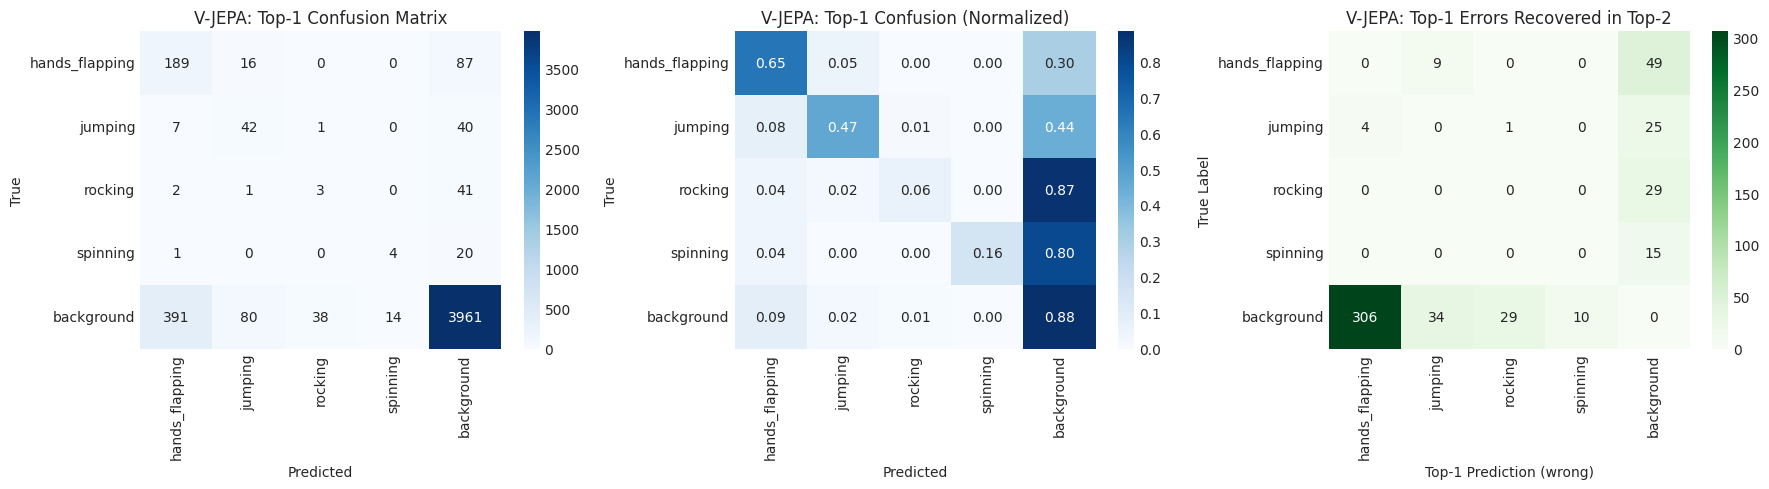


V-JEPA Summary:
  Top-1 errors: 739 (15.0%)
  Recovered in top-2: 511 (69.1% of errors)


In [7]:
cm_vjepa, recovery_vjepa = plot_confusion_matrices_top1_vs_top2(vjepa_f0, 'V-JEPA')


## Compare PoseC3D vs PoseC3D Balanced

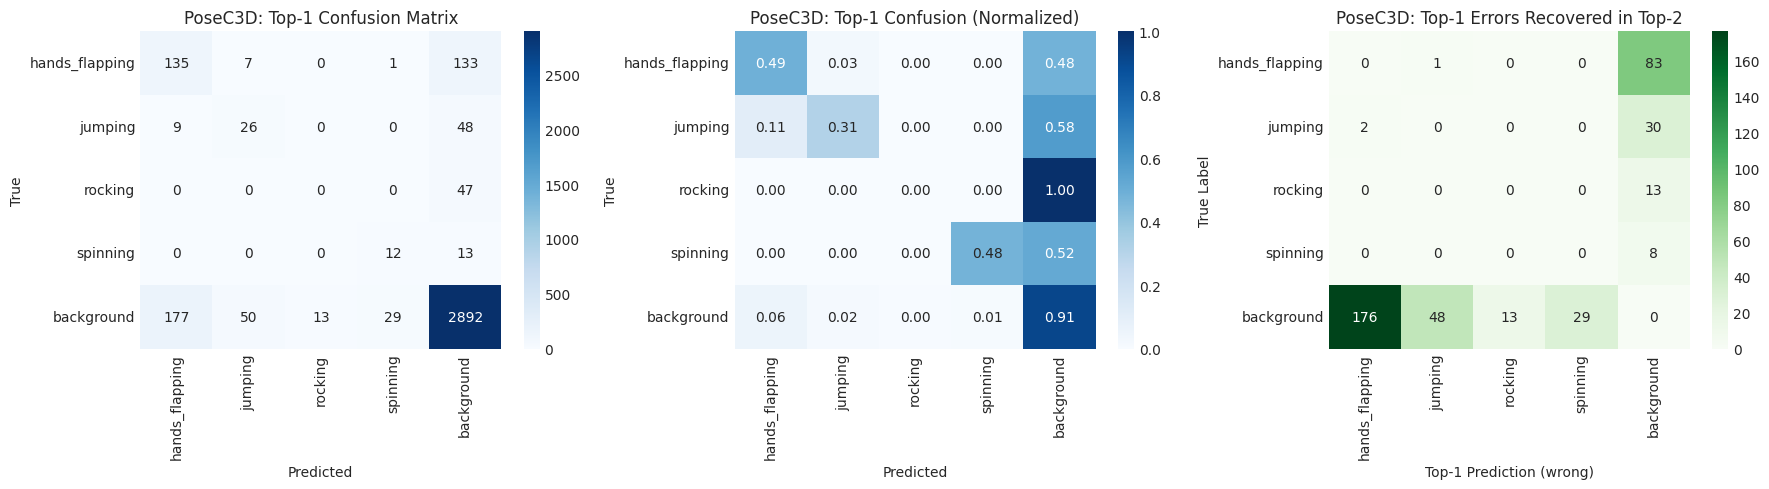


PoseC3D Summary:
  Top-1 errors: 527 (14.7%)
  Recovered in top-2: 403 (76.5% of errors)


In [18]:
cm_posec3d, recovery_posec3d = plot_confusion_matrices_top1_vs_top2(posec3d_f0, 'PoseC3D')


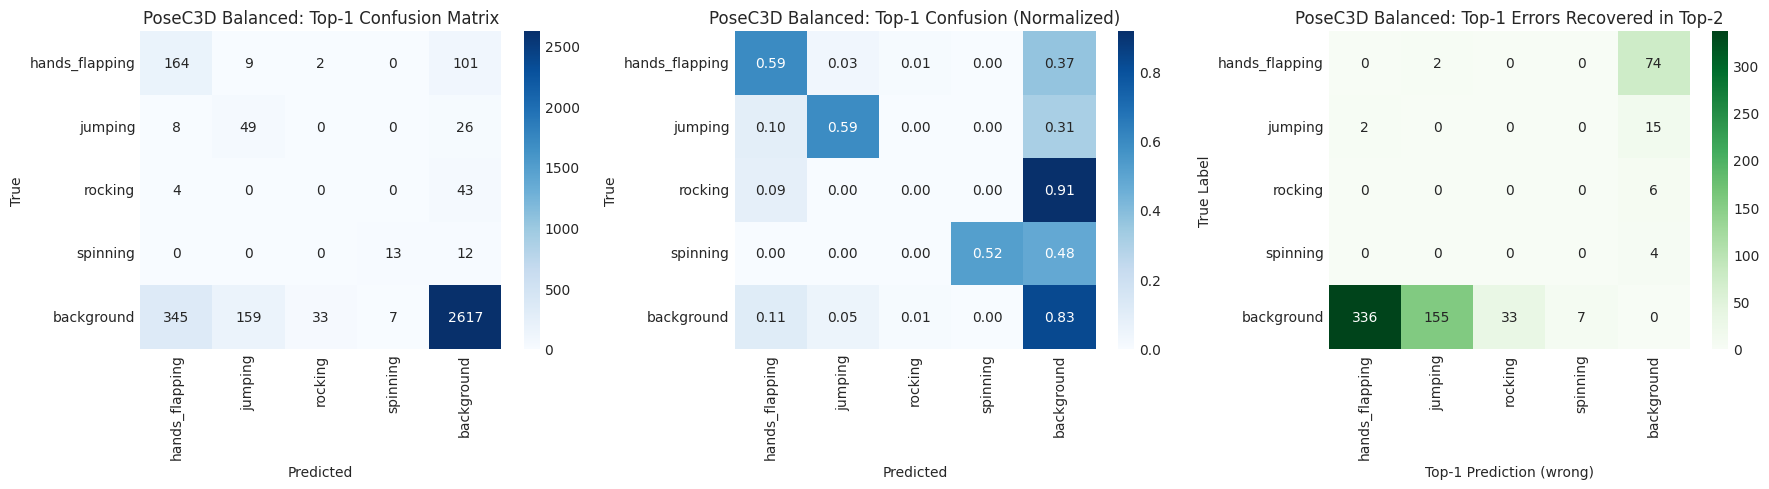


PoseC3D Balanced Summary:
  Top-1 errors: 749 (20.9%)
  Recovered in top-2: 634 (84.6% of errors)


In [19]:
cm_posec3d_bal, recovery_posec3d_bal = plot_confusion_matrices_top1_vs_top2(posec3d_balanced_f0, 'PoseC3D Balanced')

# Direct comparison

In [22]:
print("\n" + "="*60)
print("PoseC3D vs PoseC3D Balanced Comparison")
print("="*60)
print(f"{'Metric':<30} {'PoseC3D':>15} {'Balanced':>15}")
print("-"*60)

scores_orig = get_scores_array(posec3d_f0)
scores_bal = get_scores_array(posec3d_balanced_f0)
labels_orig = posec3d_f0['true_label'].values.astype(int)
labels_bal = posec3d_balanced_f0['true_label'].values.astype(int)

acc_orig = (posec3d_f0['pred_label'].values == labels_orig).mean()
acc_bal = (posec3d_balanced_f0['pred_label'].values == labels_bal).mean()
top2_orig = compute_topk_accuracy(labels_orig, scores_orig, 2)
top2_bal = compute_topk_accuracy(labels_bal, scores_bal, 2)

print(f"{'Top-1 Accuracy':<30} {acc_orig*100:>14.1f}% {acc_bal*100:>14.1f}%")
print(f"{'Top-2 Accuracy':<30} {top2_orig*100:>14.1f}% {top2_bal*100:>14.1f}%")


rmm_mask_orig = labels_orig != 4
rmm_mask_bal = labels_bal != 4
rmm_recall_orig = (posec3d_f0['pred_label'].values[rmm_mask_orig] == labels_orig[rmm_mask_orig]).mean()
rmm_recall_bal = (posec3d_balanced_f0['pred_label'].values[rmm_mask_bal] == labels_bal[rmm_mask_bal]).mean()
print(f"{'RMM Recall':<30} {rmm_recall_orig*100:>14.1f}% {rmm_recall_bal*100:>14.1f}%")


print("\nPer-Class Recall:")
for c in range(4):
    mask_orig = labels_orig == c
    mask_bal = labels_bal == c
    if mask_orig.sum() > 0:
        rec_orig = (posec3d_f0['pred_label'].values[mask_orig] == c).mean()
    else:
        rec_orig = 0
    if mask_bal.sum() > 0:
        rec_bal = (posec3d_balanced_f0['pred_label'].values[mask_bal] == c).mean()
    else:
        rec_bal = 0
    print(f"  {CLASS_NAMES[c]:<26} {rec_orig*100:>14.1f}% {rec_bal*100:>14.1f}%")


PoseC3D vs PoseC3D Balanced Comparison
Metric                                 PoseC3D        Balanced
------------------------------------------------------------
Top-1 Accuracy                           85.3%           79.1%
Top-2 Accuracy                           96.5%           96.8%
RMM Recall                               40.1%           52.4%

Per-Class Recall:
  hands_flapping                       48.9%           59.4%
  jumping                              31.3%           59.0%
  rocking                               0.0%            0.0%
  spinning                             48.0%           52.0%


In [23]:
def analyze_background_fp_recovery(df: pd.DataFrame, model_name: str):
    """Analyze background false positive recovery at top-2."""
    scores = get_scores_array(df)
    true_labels = df['true_label'].values.astype(int)
    pred_labels = df['pred_label'].values.astype(int)
    
    BG_CLASS = 4  # background
    
    # Background windows misclassified as RMM
    bg_windows = true_labels == BG_CLASS
    bg_misclass = bg_windows & (pred_labels != BG_CLASS)
    
    # Get second-choice predictions for misclassified background windows
    top2_preds = np.argsort(scores, axis=1)[:, -2:]  # [n, 2] with top-2 indices
    
    # For misclassified BG, is background the 2nd choice?
    bg_misclass_indices = np.where(bg_misclass)[0]
    second_choice = top2_preds[bg_misclass_indices, 0]  # 2nd highest (index 0 of sorted top-2)
    
    bg_as_second = (second_choice == BG_CLASS).sum()
    total_bg_misclass = len(bg_misclass_indices)
    
    print(f"\n=== {model_name}: Background FP Analysis ===")
    print(f"Total background windows: {bg_windows.sum()}")
    print(f"Background correctly classified (TP): {(bg_windows & (pred_labels == BG_CLASS)).sum()}")
    print(f"Background misclassified as RMM (FP for RMM): {total_bg_misclass}")
    if total_bg_misclass > 0:
        print(f"  Of these, background was 2nd choice: {bg_as_second} ({bg_as_second/total_bg_misclass*100:.1f}%)")
    
    # What RMM classes are BG confused with?
    if total_bg_misclass > 0:
        print(f"\n  Background misclassified as:")
        for c in range(4):  # RMM classes
            count = (pred_labels[bg_misclass] == c).sum()
            if count > 0:
                print(f"    {CLASS_NAMES[c]}: {count} ({count/total_bg_misclass*100:.1f}%)")
    
    return {
        'total_bg': bg_windows.sum(),
        'bg_correct': (bg_windows & (pred_labels == BG_CLASS)).sum(),
        'bg_misclass': total_bg_misclass,
        'bg_as_second': bg_as_second,
        'recovery_rate': bg_as_second / total_bg_misclass if total_bg_misclass > 0 else 0
    }


In [24]:
bg_analysis_vjepa = analyze_background_fp_recovery(vjepa_f0, 'V-JEPA')
bg_analysis_posec3d = analyze_background_fp_recovery(posec3d_f0, 'PoseC3D')
bg_analysis_posec3d_bal = analyze_background_fp_recovery(posec3d_balanced_f0, 'PoseC3D Balanced')



=== V-JEPA: Background FP Analysis ===
Total background windows: 4484
Background correctly classified (TP): 3961
Background misclassified as RMM (FP for RMM): 523
  Of these, background was 2nd choice: 379 (72.5%)

  Background misclassified as:
    hands_flapping: 391 (74.8%)
    jumping: 80 (15.3%)
    rocking: 38 (7.3%)
    spinning: 14 (2.7%)

=== PoseC3D: Background FP Analysis ===
Total background windows: 3161
Background correctly classified (TP): 2892
Background misclassified as RMM (FP for RMM): 269
  Of these, background was 2nd choice: 266 (98.9%)

  Background misclassified as:
    hands_flapping: 177 (65.8%)
    jumping: 50 (18.6%)
    rocking: 13 (4.8%)
    spinning: 29 (10.8%)

=== PoseC3D Balanced: Background FP Analysis ===
Total background windows: 3161
Background correctly classified (TP): 2617
Background misclassified as RMM (FP for RMM): 544
  Of these, background was 2nd choice: 531 (97.6%)

  Background misclassified as:
    hands_flapping: 345 (63.4%)
    jumpi

### 1.3 RMM Recall Analysis: Top-1 vs Top-2

**Hypothesis**: Rocking/spinning have low top-1 recall but better top-2 recall (model is uncertain but correct answer is "nearby")


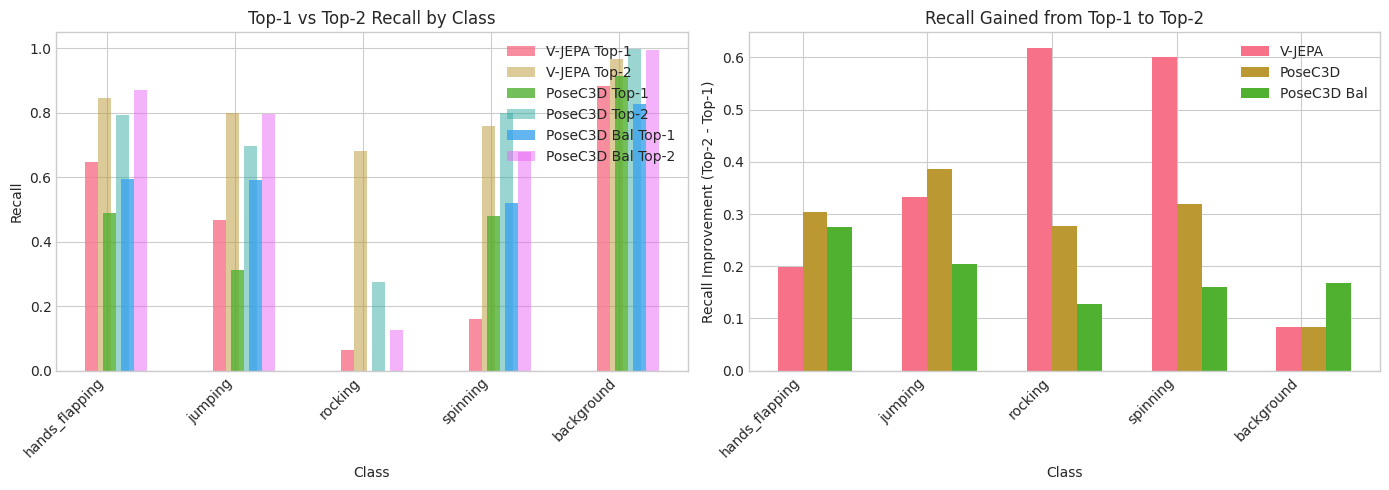


Recall Summary:
               recall_gap                    top1_recall                    top2_recall                   
model             PoseC3D PoseC3D Bal V-JEPA     PoseC3D PoseC3D Bal V-JEPA     PoseC3D PoseC3D Bal V-JEPA
class                                                                                                     
background          0.084       0.168  0.085       0.915       0.828  0.883       0.999       0.996  0.968
hands_flapping      0.304       0.275  0.199       0.489       0.594  0.647       0.793       0.870  0.846
jumping             0.386       0.205  0.333       0.313       0.590  0.467       0.699       0.795  0.800
rocking             0.277       0.128  0.617       0.000       0.000  0.064       0.277       0.128  0.681
spinning            0.320       0.160  0.600       0.480       0.520  0.160       0.800       0.680  0.760


In [25]:
def compute_and_plot_recall_comparison(datasets: dict):
    """Compare top-1 and top-2 recall across models and classes."""
    
    results = []
    for model_name, df in datasets.items():
        scores = get_scores_array(df)
        labels = df['true_label'].values.astype(int)
        
        recall_top1 = compute_topk_recall_per_class(labels, scores, 1)
        recall_top2 = compute_topk_recall_per_class(labels, scores, 2)
        
        for c in range(NUM_CLASSES):
            results.append({
                'model': model_name,
                'class': CLASS_NAMES[c],
                'class_id': c,
                'top1_recall': recall_top1[c],
                'top2_recall': recall_top2[c],
                'recall_gap': recall_top2[c] - recall_top1[c]
            })
    
    df_results = pd.DataFrame(results)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart: Top-1 vs Top-2 recall by class
    x = np.arange(NUM_CLASSES)
    width = 0.2
    
    for idx, model_name in enumerate(datasets.keys()):
        model_data = df_results[df_results['model'] == model_name]
        offset = (idx - 0.5) * width * 0.7
        
        bars1 = axes[0].bar(x + offset - width/4, model_data['top1_recall'], width/2, 
                           label=f'{model_name} Top-1', alpha=0.8)
        bars2 = axes[0].bar(x + offset + width/4, model_data['top2_recall'], width/2,
                           label=f'{model_name} Top-2', alpha=0.5)
    
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Recall')
    axes[0].set_title('Top-1 vs Top-2 Recall by Class')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    axes[0].legend(loc='upper right')
    axes[0].set_ylim(0, 1.05)
    
    # Bar chart: Recall gap (improvement from top-1 to top-2)
    for idx, model_name in enumerate(datasets.keys()):
        model_data = df_results[df_results['model'] == model_name]
        offset = (idx - 0.5) * width
        axes[1].bar(x + offset, model_data['recall_gap'], width, label=model_name)
    
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Recall Improvement (Top-2 - Top-1)')
    axes[1].set_title('Recall Gained from Top-1 to Top-2')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    axes[1].legend()
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return df_results


recall_results = compute_and_plot_recall_comparison({
    'V-JEPA': vjepa_f0,
    'PoseC3D': posec3d_f0,
    'PoseC3D Bal': posec3d_balanced_f0
})

# Print table
print("\nRecall Summary:")
pivot = recall_results.pivot_table(
    index='class', 
    columns='model',
    values=['top1_recall', 'top2_recall', 'recall_gap']
)
print(pivot.round(3).to_string())


### 1.4 Background Precision Analysis

**Question**: Does background precision improve when we consider top-2? (Fewer RMMs misclassified as background)


In [27]:
def analyze_rmm_to_bg_errors(df: pd.DataFrame, model_name: str):
    """Analyze RMM windows incorrectly classified as background."""
    scores = get_scores_array(df)
    true_labels = df['true_label'].values.astype(int)
    pred_labels = df['pred_label'].values.astype(int)
    
    BG_CLASS = 4
    
    print(f"\n=== {model_name}: RMM -> Background Error Analysis ===")
    
    total_rmm_as_bg = 0
    rmm_as_bg_recovered = 0
    
    top2_preds = np.argsort(scores, axis=1)[:, -2:]
    
    for c in range(4):  # RMM classes
        rmm_windows = true_labels == c
        rmm_as_bg = rmm_windows & (pred_labels == BG_CLASS)
        
        n_rmm = rmm_windows.sum()
        n_as_bg = rmm_as_bg.sum()
        
        if n_as_bg > 0:
            # How many have their true class in top-2?
            rmm_as_bg_indices = np.where(rmm_as_bg)[0]
            recovered = np.any(top2_preds[rmm_as_bg_indices] == c, axis=1).sum()
            
            print(f"  {CLASS_NAMES[c]}: {n_as_bg}/{n_rmm} classified as BG ({n_as_bg/n_rmm*100:.1f}%)")
            print(f"    Recovered in top-2: {recovered}/{n_as_bg} ({recovered/n_as_bg*100:.1f}%)")
            
            total_rmm_as_bg += n_as_bg
            rmm_as_bg_recovered += recovered
    
    if total_rmm_as_bg > 0:
        print(f"\n  Total RMM->BG errors: {total_rmm_as_bg}")
        print(f"  Total recovered: {rmm_as_bg_recovered} ({rmm_as_bg_recovered/total_rmm_as_bg*100:.1f}%)")
    
    return total_rmm_as_bg, rmm_as_bg_recovered


analyze_rmm_to_bg_errors(vjepa_f0, 'V-JEPA')
analyze_rmm_to_bg_errors(posec3d_f0, 'PoseC3D')
analyze_rmm_to_bg_errors(posec3d_balanced_f0, 'PoseC3D Balanced')



=== V-JEPA: RMM -> Background Error Analysis ===
  hands_flapping: 87/292 classified as BG (29.8%)
    Recovered in top-2: 49/87 (56.3%)
  jumping: 40/90 classified as BG (44.4%)
    Recovered in top-2: 25/40 (62.5%)
  rocking: 41/47 classified as BG (87.2%)
    Recovered in top-2: 29/41 (70.7%)
  spinning: 20/25 classified as BG (80.0%)
    Recovered in top-2: 15/20 (75.0%)

  Total RMM->BG errors: 188
  Total recovered: 118 (62.8%)

=== PoseC3D: RMM -> Background Error Analysis ===
  hands_flapping: 133/276 classified as BG (48.2%)
    Recovered in top-2: 83/133 (62.4%)
  jumping: 48/83 classified as BG (57.8%)
    Recovered in top-2: 30/48 (62.5%)
  rocking: 47/47 classified as BG (100.0%)
    Recovered in top-2: 13/47 (27.7%)
  spinning: 13/25 classified as BG (52.0%)
    Recovered in top-2: 8/13 (61.5%)

  Total RMM->BG errors: 241
  Total recovered: 134 (55.6%)

=== PoseC3D Balanced: RMM -> Background Error Analysis ===
  hands_flapping: 101/276 classified as BG (36.6%)
    Reco

(np.int64(182), np.int64(99))

### 2.1 Prediction Distribution Comparison

**Hypothesis**: Fusion predicts background less often, shifting mass to RMMs


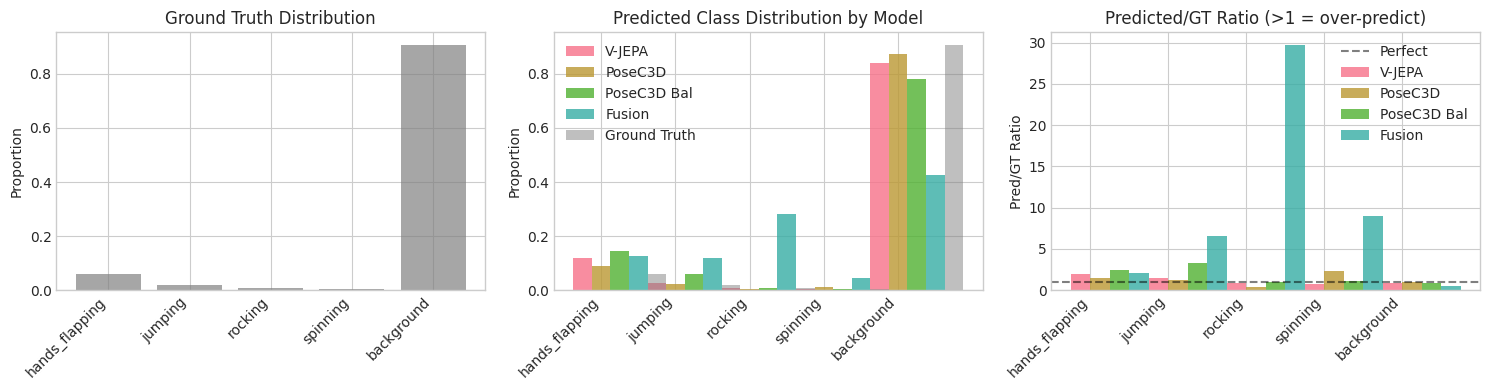


Prediction Distribution Summary:
Class                      GT   V-JEPA  PoseC3D   Fusion
------------------------------------------------------------
hands_flapping           5.9%    11.9%     8.9%    14.5%    12.6% 
jumping                  1.8%     2.8%     2.3%     6.0%    12.1% 
rocking                  1.0%     0.9%     0.4%     1.0%    28.3% 
spinning                 0.5%     0.4%     1.2%     0.6%     4.5% 
background              90.8%    84.0%    87.2%    77.9%    42.5% 


In [29]:
def plot_prediction_distribution(datasets: dict):
    """Compare predicted class distributions across models."""
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Ground truth distribution (from V-JEPA)
    gt_counts = np.bincount(datasets['V-JEPA']['true_label'].values.astype(int), minlength=NUM_CLASSES)
    gt_dist = gt_counts / gt_counts.sum()
    
    axes[0].bar(range(NUM_CLASSES), gt_dist, color='gray', alpha=0.7)
    axes[0].set_title('Ground Truth Distribution')
    axes[0].set_xticks(range(NUM_CLASSES))
    axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    axes[0].set_ylabel('Proportion')
    
    # Prediction distributions
    pred_dists = {}
    for model_name, df in datasets.items():
        pred_counts = np.bincount(df['pred_label'].values.astype(int), minlength=NUM_CLASSES)
        pred_dists[model_name] = pred_counts / pred_counts.sum()
    
    x = np.arange(NUM_CLASSES)
    width = 0.25
    
    for i, (model_name, dist) in enumerate(pred_dists.items()):
        axes[1].bar(x + i*width - width, dist, width, label=model_name, alpha=0.8)
    
    axes[1].bar(x + len(pred_dists)*width - width, gt_dist, width, label='Ground Truth', 
                color='gray', alpha=0.5, linestyle='--')
    axes[1].set_title('Predicted Class Distribution by Model')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    axes[1].set_ylabel('Proportion')
    axes[1].legend()
    
    # Ratio of predicted to ground truth
    for i, (model_name, dist) in enumerate(pred_dists.items()):
        ratio = dist / (gt_dist + 1e-10)
        axes[2].bar(x + i*width - width/2, ratio, width, label=model_name, alpha=0.8)
    
    axes[2].axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Perfect')
    axes[2].set_title('Predicted/GT Ratio (>1 = over-predict)')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    axes[2].set_ylabel('Pred/GT Ratio')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print table
    print("\nPrediction Distribution Summary:")
    print(f"{'Class':<20} {'GT':>8} {'V-JEPA':>8} {'PoseC3D':>8} {'Fusion':>8}")
    print("-" * 60)
    for c in range(NUM_CLASSES):
        print(f"{CLASS_NAMES[c]:<20} {gt_dist[c]*100:>7.1f}% ", end='')
        for model_name in pred_dists.keys():
            print(f"{pred_dists[model_name][c]*100:>7.1f}% ", end='')
        print()
    
    return pred_dists, gt_dist


pred_dists, gt_dist = plot_prediction_distribution({
    'V-JEPA': vjepa_f0,
    'PoseC3D': posec3d_f0,
    'PoseC3D Bal': posec3d_balanced_f0,
    'Fusion': fusion_f0
})


### 2.2 Confusion Matrix Comparison: V-JEPA vs PoseC3D vs Fusion


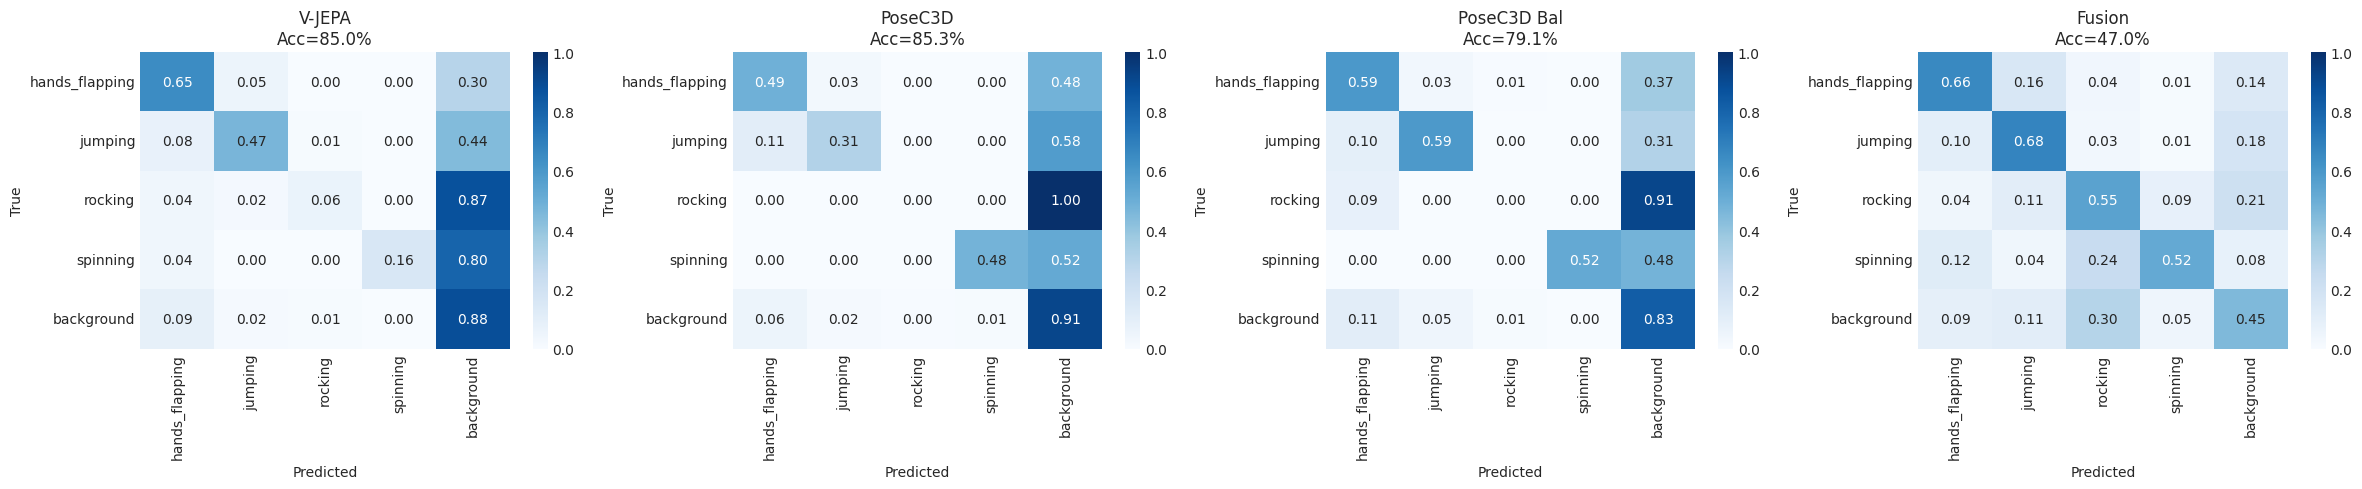

In [30]:
def plot_confusion_matrices_comparison(datasets: dict):
    """Side-by-side confusion matrices for multiple models."""
    
    n_models = len(datasets)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
    if n_models == 1:
        axes = [axes]
    
    cms = {}
    for ax, (model_name, df) in zip(axes, datasets.items()):
        true_labels = df['true_label'].values.astype(int)
        pred_labels = df['pred_label'].values.astype(int)
        
        cm = confusion_matrix(true_labels, pred_labels, labels=range(NUM_CLASSES))
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cms[model_name] = cm
        
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
        acc = (true_labels == pred_labels).mean()
        ax.set_title(f'{model_name}\nAcc={acc*100:.1f}%')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    
    plt.tight_layout()
    plt.show()
    
    return cms


cms = plot_confusion_matrices_comparison({
    'V-JEPA': vjepa_f0,
    'PoseC3D': posec3d_f0,
    'PoseC3D Bal': posec3d_balanced_f0,
    'Fusion': fusion_f0
})


### 2.3 Per-Class Precision/Recall Trade-off

**Expected**: Fusion may sacrifice background precision for RMM recall


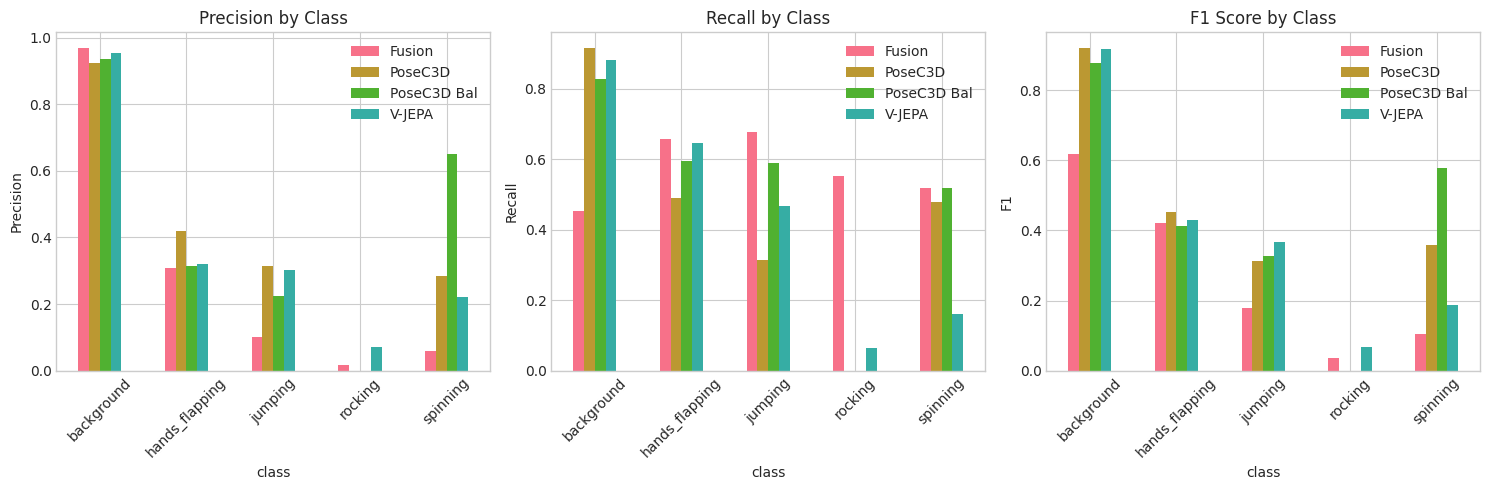


Precision/Recall Summary:
                   f1                            precision                            recall                           
model          Fusion PoseC3D PoseC3D Bal V-JEPA    Fusion PoseC3D PoseC3D Bal V-JEPA Fusion PoseC3D PoseC3D Bal V-JEPA
class                                                                                                                  
background      0.617   0.919       0.878  0.918     0.968   0.923       0.935  0.955  0.453   0.915       0.828  0.883
hands_flapping  0.420   0.452       0.412  0.429     0.309   0.421       0.315  0.320  0.658   0.489       0.594  0.647
jumping         0.178   0.313       0.327  0.367     0.102   0.313       0.226  0.302  0.678   0.313       0.590  0.467
rocking         0.036   0.000       0.000  0.067     0.019   0.000       0.000  0.071  0.553   0.000       0.000  0.064
spinning        0.104   0.358       0.578  0.186     0.058   0.286       0.650  0.222  0.520   0.480       0.520  0.160


In [31]:
def compute_precision_recall_f1(datasets: dict):
    """Compute precision, recall, F1 for each class across models."""
    
    results = []
    for model_name, df in datasets.items():
        true_labels = df['true_label'].values.astype(int)
        pred_labels = df['pred_label'].values.astype(int)
        
        prec, rec, f1, support = precision_recall_fscore_support(
            true_labels, pred_labels, labels=range(NUM_CLASSES), zero_division=0
        )
        
        for c in range(NUM_CLASSES):
            results.append({
                'model': model_name,
                'class': CLASS_NAMES[c],
                'class_id': c,
                'precision': prec[c],
                'recall': rec[c],
                'f1': f1[c],
                'support': support[c]
            })
    
    return pd.DataFrame(results)


pr_results = compute_precision_recall_f1({
    'V-JEPA': vjepa_f0,
    'PoseC3D': posec3d_f0,
    'PoseC3D Bal': posec3d_balanced_f0,
    'Fusion': fusion_f0
})

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Precision by class
pivot_prec = pr_results.pivot(index='class', columns='model', values='precision')
pivot_prec.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Precision by Class')
axes[0].set_ylabel('Precision')
axes[0].legend(loc='upper right')

# Recall by class
pivot_rec = pr_results.pivot(index='class', columns='model', values='recall')
pivot_rec.plot(kind='bar', ax=axes[1], rot=45)
axes[1].set_title('Recall by Class')
axes[1].set_ylabel('Recall')
axes[1].legend(loc='upper right')

# F1 by class
pivot_f1 = pr_results.pivot(index='class', columns='model', values='f1')
pivot_f1.plot(kind='bar', ax=axes[2], rot=45)
axes[2].set_title('F1 Score by Class')
axes[2].set_ylabel('F1')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print summary table
print("\nPrecision/Recall Summary:")
print(pr_results.pivot_table(
    index='class',
    columns='model',
    values=['precision', 'recall', 'f1']
).round(3).to_string())


### 2.4 TAL-Specific Analysis: Error Type Distribution

**Key insight**: TAL mAP only cares about RMM classes. Background errors affect:
- BG->RMM: Creates false positive detections (hurts precision)
- RMM->BG: Creates false negative detections (hurts recall)


### 2.5 Confidence Distribution Analysis

**Question**: Does fusion have more "spread out" confidence, leading to more RMM predictions?


Error Type Analysis:
      model  correct_pct  bg_to_rmm_pct  rmm_to_bg_pct  rmm_to_wrong_rmm_pct
     V-JEPA    85.034427      10.591333       3.807209              0.567031
    PoseC3D    85.328508       7.488864       6.709354              0.473274
PoseC3D Bal    79.148107      15.144766       5.066815              0.640312
     Fusion    47.023086      49.696233       1.377076              1.903605


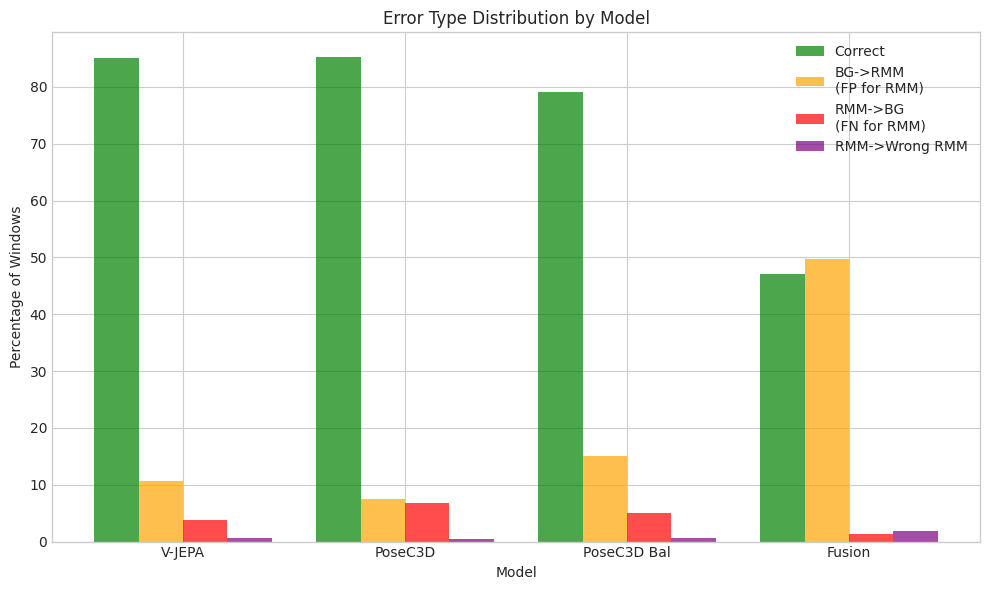


=== Key Insight ===
TAL mAP only evaluates RMM classes. Error impact:
  - BG->RMM (false positives): Hurts TAL precision
  - RMM->BG (false negatives): Hurts TAL recall (worse for rare classes)
  - RMM->wrong RMM: Hurts both (mislocalization + misclassification)


In [32]:
def analyze_error_types(df: pd.DataFrame, model_name: str):
    """Categorize errors by type."""
    true_labels = df['true_label'].values.astype(int)
    pred_labels = df['pred_label'].values.astype(int)
    
    BG = 4
    
    # Error types
    correct = true_labels == pred_labels
    bg_to_rmm = (true_labels == BG) & (pred_labels != BG)  # False positive for RMM
    rmm_to_bg = (true_labels != BG) & (pred_labels == BG)  # False negative for RMM
    rmm_to_wrong_rmm = (true_labels != BG) & (pred_labels != BG) & (true_labels != pred_labels)
    
    n_total = len(true_labels)
    
    return {
        'model': model_name,
        'correct': correct.sum(),
        'correct_pct': correct.mean() * 100,
        'bg_to_rmm': bg_to_rmm.sum(),
        'bg_to_rmm_pct': bg_to_rmm.mean() * 100,
        'rmm_to_bg': rmm_to_bg.sum(),
        'rmm_to_bg_pct': rmm_to_bg.mean() * 100,
        'rmm_to_wrong_rmm': rmm_to_wrong_rmm.sum(),
        'rmm_to_wrong_rmm_pct': rmm_to_wrong_rmm.mean() * 100,
        'total': n_total
    }


error_analysis = pd.DataFrame([
    analyze_error_types(vjepa_f0, 'V-JEPA'),
    analyze_error_types(posec3d_f0, 'PoseC3D'),
    analyze_error_types(posec3d_balanced_f0, 'PoseC3D Bal'),
    analyze_error_types(fusion_f0, 'Fusion')
])

print("Error Type Analysis:")
print(error_analysis[['model', 'correct_pct', 'bg_to_rmm_pct', 'rmm_to_bg_pct', 'rmm_to_wrong_rmm_pct']].to_string(index=False))

# Plot error distribution
fig, ax = plt.subplots(figsize=(10, 6))

error_types = ['correct_pct', 'bg_to_rmm_pct', 'rmm_to_bg_pct', 'rmm_to_wrong_rmm_pct']
labels = ['Correct', 'BG->RMM\n(FP for RMM)', 'RMM->BG\n(FN for RMM)', 'RMM->Wrong RMM']

x = np.arange(len(error_analysis))
width = 0.2
colors = ['green', 'orange', 'red', 'purple']

for i, (err_type, label, color) in enumerate(zip(error_types, labels, colors)):
    ax.bar(x + i*width - 1.5*width, error_analysis[err_type], width, label=label, color=color, alpha=0.7)

ax.set_xlabel('Model')
ax.set_ylabel('Percentage of Windows')
ax.set_title('Error Type Distribution by Model')
ax.set_xticks(x)
ax.set_xticklabels(error_analysis['model'])
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n=== Key Insight ===")
print("TAL mAP only evaluates RMM classes. Error impact:")
print("  - BG->RMM (false positives): Hurts TAL precision")
print("  - RMM->BG (false negatives): Hurts TAL recall (worse for rare classes)")
print("  - RMM->wrong RMM: Hurts both (mislocalization + misclassification)")


### 2.6 Deep Dive: Confidence Analysis for Error Cases

**Key Questions:**
1. When background is misclassified as RMM (FP), what is the confidence?
2. Can we threshold to reject low-confidence RMM predictions?
3. What's the precision/recall trade-off at different thresholds?


V-JEPA Confidence Analysis


/tmp/ipykernel_3976470/4244641282.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)


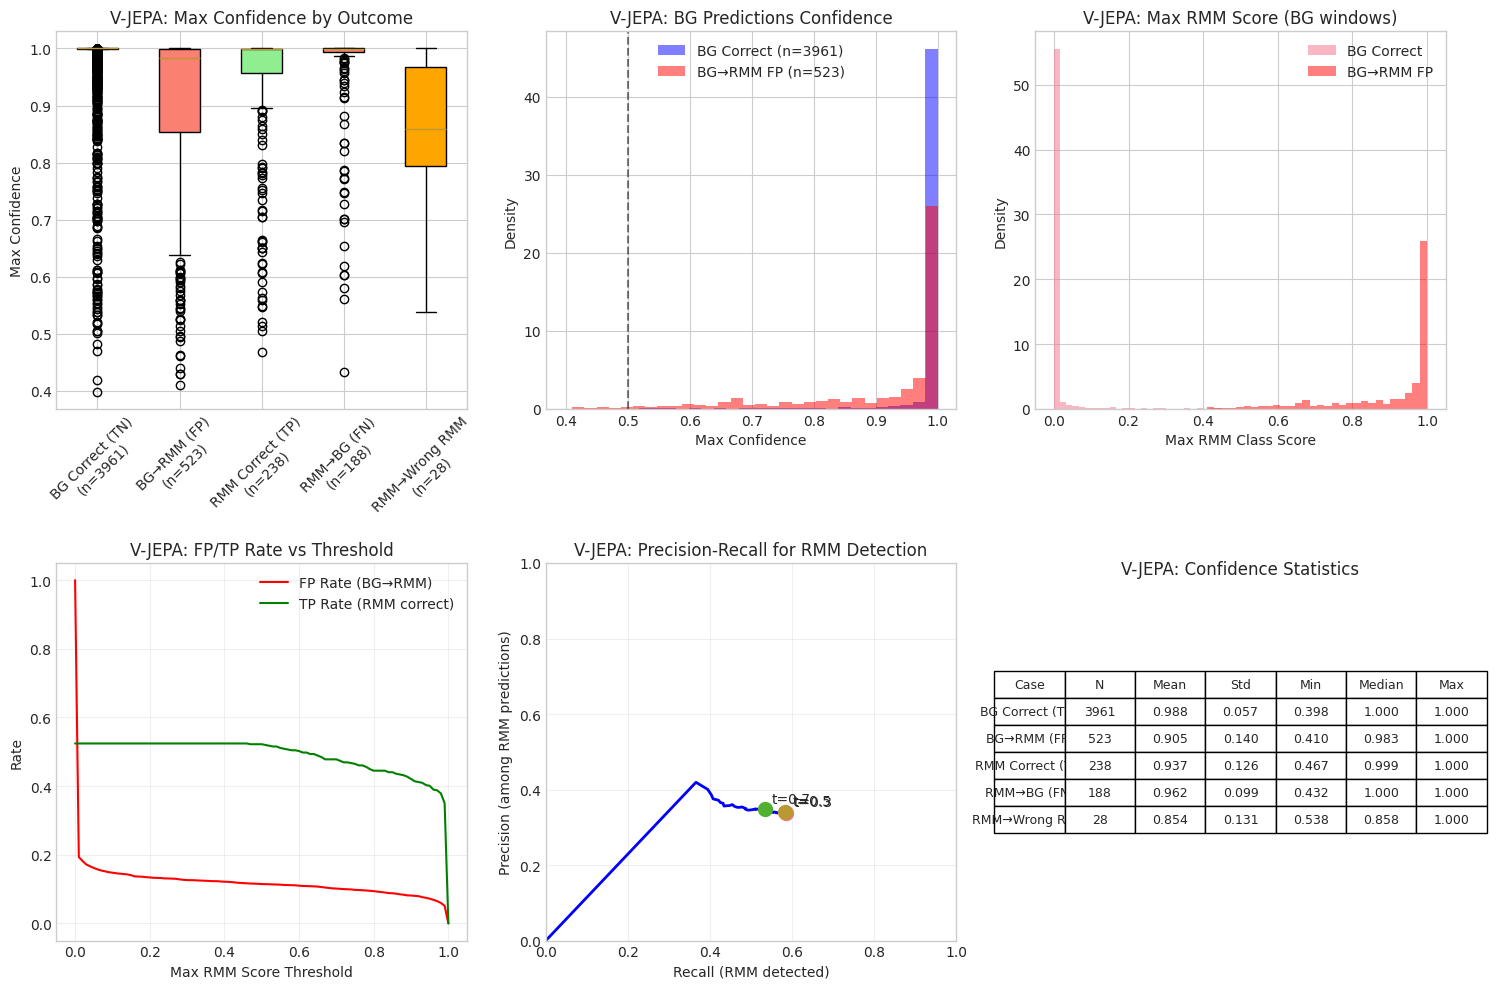

In [38]:
def analyze_confidence_by_error_type(df: pd.DataFrame, model_name: str):
    """Analyze confidence distributions for different prediction outcomes."""
    scores = get_scores_array(df)
    true_labels = df['true_label'].values.astype(int)
    pred_labels = df['pred_label'].values.astype(int)
    
    BG = 4
    max_conf = scores.max(axis=1)
    max_rmm_score = scores[:, :4].max(axis=1)
    bg_score = scores[:, BG]
    
    # Define cases
    bg_windows = true_labels == BG
    rmm_windows = true_labels != BG
    
    # Correct predictions
    bg_correct = bg_windows & (pred_labels == BG)
    rmm_correct = rmm_windows & (pred_labels == true_labels)
    
    # Errors
    bg_to_rmm = bg_windows & (pred_labels != BG)  # BG predicted as RMM (FP for RMM)
    rmm_to_bg = rmm_windows & (pred_labels == BG)  # RMM predicted as BG (FN for RMM)
    rmm_to_wrong = rmm_windows & (pred_labels != BG) & (pred_labels != true_labels)
    
    cases = {
        'BG Correct (TN)': bg_correct,
        'BG→RMM (FP)': bg_to_rmm,
        'RMM Correct (TP)': rmm_correct,
        'RMM→BG (FN)': rmm_to_bg,
        'RMM→Wrong RMM': rmm_to_wrong
    }
    
    # Plot confidence distributions
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Max confidence by case
    ax = axes[0, 0]
    data_to_plot = []
    labels_to_plot = []
    for case_name, mask in cases.items():
        if mask.sum() > 0:
            data_to_plot.append(max_conf[mask])
            labels_to_plot.append(f'{case_name}\n(n={mask.sum()})')
    
    bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)
    colors = ['lightgreen', 'salmon', 'lightgreen', 'salmon', 'orange']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
    ax.set_ylabel('Max Confidence')
    ax.set_title(f'{model_name}: Max Confidence by Outcome')
    ax.tick_params(axis='x', rotation=45)
    
    # 2. Histogram: BG Correct vs BG→RMM
    ax = axes[0, 1]
    if bg_correct.sum() > 0:
        ax.hist(max_conf[bg_correct], bins=30, alpha=0.5, label=f'BG Correct (n={bg_correct.sum()})', density=True, color='blue')
    if bg_to_rmm.sum() > 0:
        ax.hist(max_conf[bg_to_rmm], bins=30, alpha=0.5, label=f'BG→RMM FP (n={bg_to_rmm.sum()})', density=True, color='red')
    ax.set_xlabel('Max Confidence')
    ax.set_ylabel('Density')
    ax.set_title(f'{model_name}: BG Predictions Confidence')
    ax.legend()
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='0.5 threshold')
    
    # 3. Max RMM score for BG windows
    ax = axes[0, 2]
    if bg_correct.sum() > 0:
        ax.hist(max_rmm_score[bg_correct], bins=30, alpha=0.5, label='BG Correct', density=True)
    if bg_to_rmm.sum() > 0:
        ax.hist(max_rmm_score[bg_to_rmm], bins=30, alpha=0.5, label='BG→RMM FP', density=True, color='red')
    ax.set_xlabel('Max RMM Class Score')
    ax.set_ylabel('Density')
    ax.set_title(f'{model_name}: Max RMM Score (BG windows)')
    ax.legend()
    
    # 4. ROC-like: Threshold vs FP/TP rates
    ax = axes[1, 0]
    thresholds = np.linspace(0, 1, 101)
    fp_rates = []  # BG→RMM at each threshold
    tp_rates = []  # RMM correctly detected at each threshold
    
    for thresh in thresholds:
        # Predict RMM if max_rmm_score > thresh AND max_rmm_score > bg_score
        pred_rmm = (max_rmm_score > thresh)
        
        fp_rate = pred_rmm[bg_windows].mean() if bg_windows.sum() > 0 else 0
        tp_rate = ((pred_rmm) & (pred_labels == true_labels))[rmm_windows].mean() if rmm_windows.sum() > 0 else 0
        
        fp_rates.append(fp_rate)
        tp_rates.append(tp_rate)
    
    ax.plot(thresholds, fp_rates, label='FP Rate (BG→RMM)', color='red')
    ax.plot(thresholds, tp_rates, label='TP Rate (RMM correct)', color='green')
    ax.set_xlabel('Max RMM Score Threshold')
    ax.set_ylabel('Rate')
    ax.set_title(f'{model_name}: FP/TP Rate vs Threshold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. Precision-Recall curve for RMM detection
    ax = axes[1, 1]
    precisions = []
    recalls = []
    
    for thresh in thresholds:
        pred_rmm = (max_rmm_score > thresh) & (max_rmm_score > bg_score)
        
        # Precision = TP / (TP + FP)
        tp = (pred_rmm & rmm_windows).sum()
        fp = (pred_rmm & bg_windows).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        
        # Recall = TP / (TP + FN)
        fn = ((~pred_rmm) & rmm_windows).sum()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
    
    ax.plot(recalls, precisions, 'b-', linewidth=2)
    ax.set_xlabel('Recall (RMM detected)')
    ax.set_ylabel('Precision (among RMM predictions)')
    ax.set_title(f'{model_name}: Precision-Recall for RMM Detection')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Mark some key thresholds
    for thresh_val in [0.3, 0.5, 0.7]:
        idx = int(thresh_val * 100)
        if idx < len(precisions):
            ax.scatter([recalls[idx]], [precisions[idx]], s=100, zorder=5)
            ax.annotate(f't={thresh_val}', (recalls[idx], precisions[idx]), 
                       textcoords="offset points", xytext=(5, 5))
    
    # 6. Summary statistics table
    ax = axes[1, 2]
    ax.axis('off')
    
    summary_data = []
    for case_name, mask in cases.items():
        if mask.sum() > 0:
            summary_data.append([
                case_name,
                mask.sum(),
                f'{max_conf[mask].mean():.3f}',
                f'{max_conf[mask].std():.3f}',
                f'{max_conf[mask].min():.3f}',
                f'{np.median(max_conf[mask]):.3f}',
                f'{max_conf[mask].max():.3f}'
            ])
    
    table = ax.table(
        cellText=summary_data,
        colLabels=['Case', 'N', 'Mean', 'Std', 'Min', 'Median', 'Max'],
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    ax.set_title(f'{model_name}: Confidence Statistics', y=0.95)
    
    plt.tight_layout()
    plt.show()
    
    return cases, max_conf, max_rmm_score, bg_score


# Analyze each model
print("="*80)
print("V-JEPA Confidence Analysis")
print("="*80)
vjepa_cases, vjepa_conf, vjepa_rmm, vjepa_bg = analyze_confidence_by_error_type(vjepa_f0, 'V-JEPA')


In [39]:
def find_optimal_thresholds(df: pd.DataFrame, model_name: str):
    """Find optimal thresholds for different objectives."""
    scores = get_scores_array(df)
    true_labels = df['true_label'].values.astype(int)
    
    BG = 4
    max_rmm_score = scores[:, :4].max(axis=1)
    bg_windows = true_labels == BG
    rmm_windows = true_labels != BG
    
    thresholds = np.linspace(0, 1, 201)
    results = []
    
    for thresh in thresholds:
        pred_rmm = max_rmm_score > thresh
        tp = (pred_rmm & rmm_windows).sum()
        fp = (pred_rmm & bg_windows).sum()
        fn = ((~pred_rmm) & rmm_windows).sum()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        fp_rate = fp / bg_windows.sum() if bg_windows.sum() > 0 else 0
        
        results.append({'threshold': thresh, 'precision': precision, 'recall': recall, 
                       'f1': f1, 'fp_rate': fp_rate, 'tp': tp, 'fp': fp})
    
    df_results = pd.DataFrame(results)
    
    # Find optimal points
    max_f1_idx = df_results['f1'].idxmax()
    max_f1_row = df_results.loc[max_f1_idx]
    
    fp10_df = df_results[df_results['fp_rate'] < 0.10]
    fp10_row = fp10_df.loc[fp10_df['recall'].idxmax()] if len(fp10_df) > 0 else None
    
    fp5_df = df_results[df_results['fp_rate'] < 0.05]
    fp5_row = fp5_df.loc[fp5_df['recall'].idxmax()] if len(fp5_df) > 0 else None
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    ax = axes[0]
    ax.plot(df_results['threshold'], df_results['precision'], label='Precision')
    ax.plot(df_results['threshold'], df_results['recall'], label='Recall')
    ax.plot(df_results['threshold'], df_results['f1'], label='F1', linewidth=2)
    ax.axvline(max_f1_row['threshold'], color='purple', linestyle='--', alpha=0.5)
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.set_title(f'{model_name}: Metrics vs Threshold')
    ax.legend(); ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.plot(df_results['threshold'], df_results['fp_rate'] * 100, color='red', linewidth=2)
    ax.axhline(5, color='orange', linestyle='--', alpha=0.5, label='5% target')
    ax.axhline(10, color='yellow', linestyle='--', alpha=0.5, label='10% target')
    ax.set_xlabel('Threshold'); ax.set_ylabel('FP Rate (%)')
    ax.set_title(f'{model_name}: BG→RMM FP Rate')
    ax.legend(); ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{model_name} Optimal Thresholds:")
    print(f"  Max F1: t={max_f1_row['threshold']:.2f} → P={max_f1_row['precision']*100:.1f}%, R={max_f1_row['recall']*100:.1f}%, F1={max_f1_row['f1']*100:.1f}%, FP={max_f1_row['fp_rate']*100:.1f}%")
    if fp10_row is not None:
        print(f"  FP<10%: t={fp10_row['threshold']:.2f} → P={fp10_row['precision']*100:.1f}%, R={fp10_row['recall']*100:.1f}%, FP={fp10_row['fp_rate']*100:.1f}%")
    if fp5_row is not None:
        print(f"  FP<5%:  t={fp5_row['threshold']:.2f} → P={fp5_row['precision']*100:.1f}%, R={fp5_row['recall']*100:.1f}%, FP={fp5_row['fp_rate']*100:.1f}%")
    
    return df_results, max_f1_row, fp10_row, fp5_row


V-JEPA Threshold Analysis


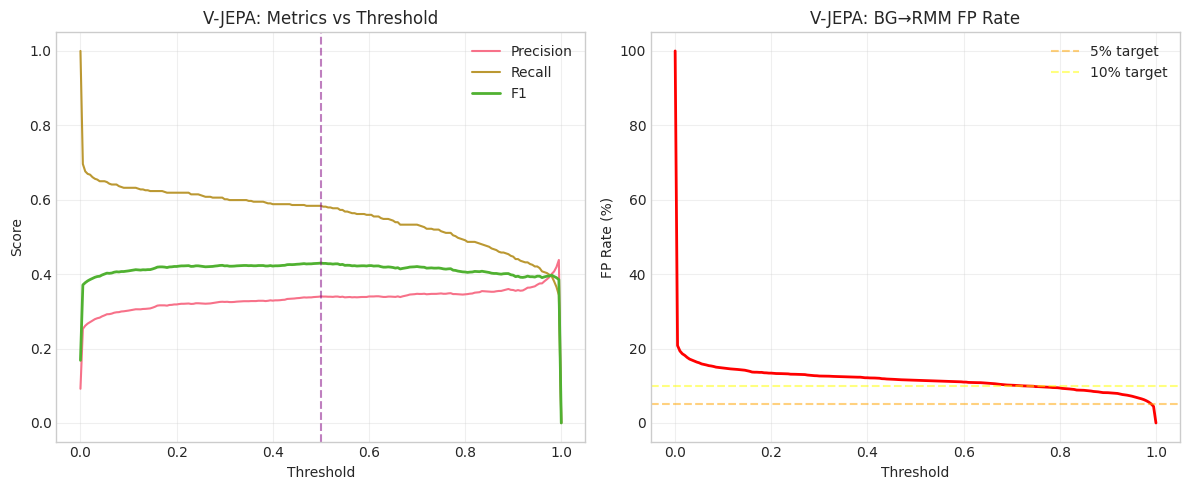


V-JEPA Optimal Thresholds:
  Max F1: t=0.50 → P=34.0%, R=58.4%, F1=43.0%, FP=11.5%
  FP<10%: t=0.72 → P=34.6%, R=52.2%, FP=10.0%
  FP<5%:  t=0.99 → P=43.8%, R=34.4%, FP=4.5%

PoseC3D Threshold Analysis


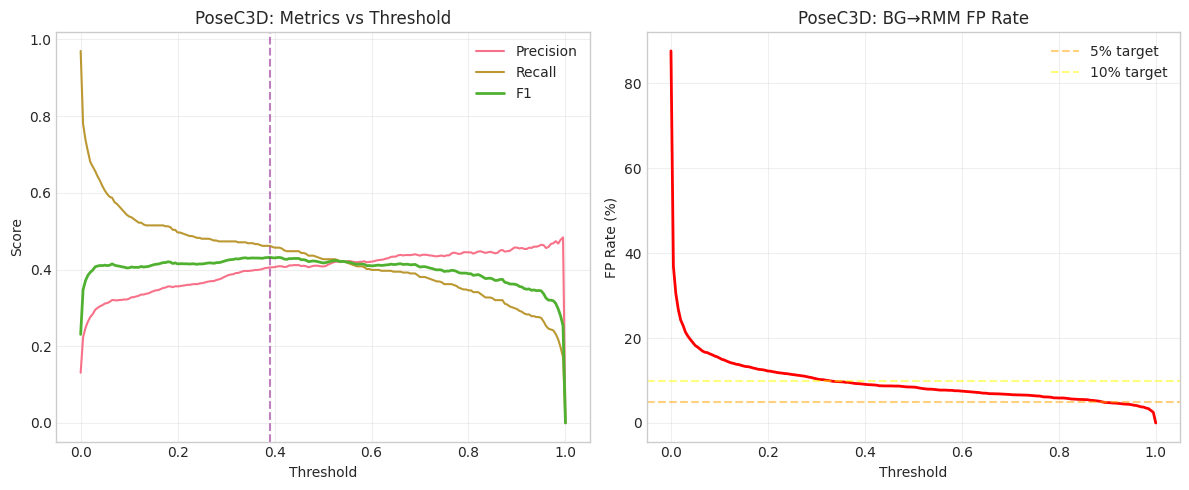


PoseC3D Optimal Thresholds:
  Max F1: t=0.39 → P=40.5%, R=46.2%, F1=43.2%, FP=9.2%
  FP<10%: t=0.33 → P=39.1%, R=47.1%, FP=10.0%
  FP<5%:  t=0.89 → P=45.3%, R=30.2%, FP=5.0%

PoseC3D Balanced Threshold Analysis


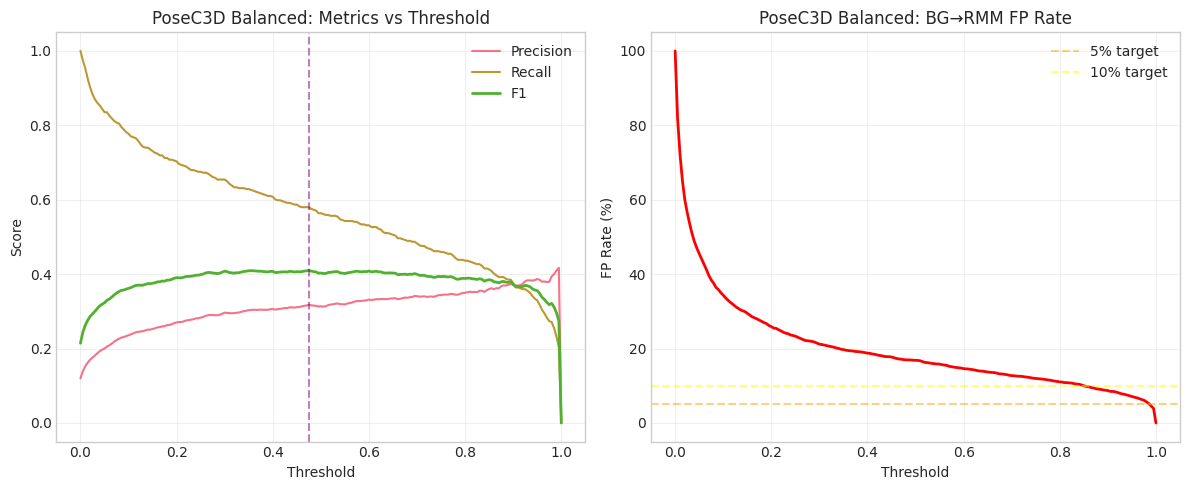


PoseC3D Balanced Optimal Thresholds:
  Max F1: t=0.48 → P=31.7%, R=58.0%, F1=41.0%, FP=17.0%
  FP<10%: t=0.85 → P=36.0%, R=41.3%, FP=10.0%
  FP<5%:  t=0.99 → P=41.0%, R=23.2%, FP=4.6%


In [40]:
# Run threshold optimization for all models
print("="*80)
print("V-JEPA Threshold Analysis")
print("="*80)
vjepa_thresh, vjepa_max_f1, vjepa_fp10, vjepa_fp5 = find_optimal_thresholds(vjepa_f0, 'V-JEPA')

print("\n" + "="*80)
print("PoseC3D Threshold Analysis")
print("="*80)
posec3d_thresh, posec3d_max_f1, posec3d_fp10, posec3d_fp5 = find_optimal_thresholds(posec3d_f0, 'PoseC3D')

print("\n" + "="*80)
print("PoseC3D Balanced Threshold Analysis")
print("="*80)
posec3d_bal_thresh, posec3d_bal_max_f1, posec3d_bal_fp10, posec3d_bal_fp5 = find_optimal_thresholds(posec3d_balanced_f0, 'PoseC3D Balanced')


In [41]:
# Summary comparison of threshold strategies
print("="*80)
print("THRESHOLD STRATEGY COMPARISON")
print("="*80)

print("\n1. MAX F1 OPERATING POINT:")
print(f"   {'Model':<20} {'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'FP Rate':>10}")
print("   " + "-"*70)
for name, row in [('V-JEPA', vjepa_max_f1), ('PoseC3D', posec3d_max_f1), ('PoseC3D Bal', posec3d_bal_max_f1)]:
    print(f"   {name:<20} {row['threshold']:>10.2f} {row['precision']*100:>9.1f}% {row['recall']*100:>9.1f}% {row['f1']*100:>9.1f}% {row['fp_rate']*100:>9.1f}%")

print("\n2. FP<10% OPERATING POINT (maximize recall while keeping FP under 10%):")
print(f"   {'Model':<20} {'Threshold':>10} {'Precision':>10} {'Recall':>10} {'FP Rate':>10}")
print("   " + "-"*60)
for name, row in [('V-JEPA', vjepa_fp10), ('PoseC3D', posec3d_fp10), ('PoseC3D Bal', posec3d_bal_fp10)]:
    if row is not None:
        print(f"   {name:<20} {row['threshold']:>10.2f} {row['precision']*100:>9.1f}% {row['recall']*100:>9.1f}% {row['fp_rate']*100:>9.1f}%")
    else:
        print(f"   {name:<20} {'N/A':>10} (cannot achieve FP<10%)")

print("\n3. FP<5% OPERATING POINT:")
print(f"   {'Model':<20} {'Threshold':>10} {'Precision':>10} {'Recall':>10} {'FP Rate':>10}")
print("   " + "-"*60)
for name, row in [('V-JEPA', vjepa_fp5), ('PoseC3D', posec3d_fp5), ('PoseC3D Bal', posec3d_bal_fp5)]:
    if row is not None:
        print(f"   {name:<20} {row['threshold']:>10.2f} {row['precision']*100:>9.1f}% {row['recall']*100:>9.1f}% {row['fp_rate']*100:>9.1f}%")
    else:
        print(f"   {name:<20} {'N/A':>10} (cannot achieve FP<5%)")

print("\n" + "="*80)
print("KEY INSIGHT: Thresholding on max RMM score CAN reduce false positives!")
print("="*80)
print("""
For TAL post-processing, consider:
1. Apply a confidence threshold BEFORE smoothing/merging
2. Use model-specific thresholds based on the trade-offs above
3. V-JEPA may need higher threshold (~0.1-0.2) to cut FP to <10%
4. PoseC3D naturally has lower FP rate, threshold ~0.05-0.1 suffices
""")


THRESHOLD STRATEGY COMPARISON

1. MAX F1 OPERATING POINT:
   Model                 Threshold  Precision     Recall         F1    FP Rate
   ----------------------------------------------------------------------
   V-JEPA                     0.50      34.0%      58.4%      43.0%      11.5%
   PoseC3D                    0.39      40.5%      46.2%      43.2%       9.2%
   PoseC3D Bal                0.48      31.7%      58.0%      41.0%      17.0%

2. FP<10% OPERATING POINT (maximize recall while keeping FP under 10%):
   Model                 Threshold  Precision     Recall    FP Rate
   ------------------------------------------------------------
   V-JEPA                     0.72      34.6%      52.2%      10.0%
   PoseC3D                    0.33      39.1%      47.1%      10.0%
   PoseC3D Bal                0.85      36.0%      41.3%      10.0%

3. FP<5% OPERATING POINT:
   Model                 Threshold  Precision     Recall    FP Rate
   ---------------------------------------------

### 2.8 Key Finding: FPs are High-Confidence Errors!

**Critical insight from the analysis above:**
- BG→RMM false positives have **high confidence** (V-JEPA mean=0.90, PoseC3D mean=0.86)
- Simple thresholding on max score **cannot effectively filter** these FPs
- The models are confidently wrong, not uncertainly wrong

**What this means:**
1. These aren't "borderline" predictions - the model genuinely believes it's seeing RMM
2. The issue is likely **visual/motion similarity** between some background activities and RMM
3. Need to look at **what the FP windows actually contain** (e.g., hands_flapping FPs might be waving/gesturing)


In [42]:
# Explore alternative filtering strategies
def analyze_fp_characteristics(df: pd.DataFrame, model_name: str):
    """Analyze characteristics of false positive predictions."""
    scores = get_scores_array(df)
    true_labels = df['true_label'].values.astype(int)
    pred_labels = df['pred_label'].values.astype(int)
    
    BG = 4
    max_conf = scores.max(axis=1)
    max_rmm = scores[:, :4].max(axis=1)
    bg_score = scores[:, BG]
    
    bg_windows = true_labels == BG
    bg_to_rmm = bg_windows & (pred_labels != BG)
    
    print(f"\n{'='*60}")
    print(f"{model_name}: FALSE POSITIVE ANALYSIS")
    print(f"{'='*60}")
    
    # 1. Which RMM class are BG confused with?
    print("\n1. FP Distribution by Predicted Class:")
    fp_preds = pred_labels[bg_to_rmm]
    for c in range(4):
        count = (fp_preds == c).sum()
        pct = count / len(fp_preds) * 100 if len(fp_preds) > 0 else 0
        print(f"   {CLASS_NAMES[c]}: {count} ({pct:.1f}%)")
    
    # 2. Confidence comparison: FP vs TP for each class
    print("\n2. Confidence: FP vs True Positive by Class")
    rmm_correct = (true_labels != BG) & (pred_labels == true_labels)
    
    print(f"   {'Class':<20} {'TP Conf (mean)':>15} {'FP Conf (mean)':>15} {'Separable?':>12}")
    print("   " + "-"*65)
    for c in range(4):
        # True positives for this class
        tp_mask = rmm_correct & (true_labels == c)
        tp_conf = max_conf[tp_mask].mean() if tp_mask.sum() > 0 else 0
        
        # False positives predicted as this class
        fp_mask = bg_to_rmm & (pred_labels == c)
        fp_conf = max_conf[fp_mask].mean() if fp_mask.sum() > 0 else 0
        
        # Are they separable?
        separable = "Maybe" if abs(tp_conf - fp_conf) > 0.1 else "No"
        print(f"   {CLASS_NAMES[c]:<20} {tp_conf:>14.3f} {fp_conf:>14.3f} {separable:>12}")
    
    # 3. Score margin analysis: (max_rmm - bg_score)
    print("\n3. Score Margin Analysis: (max_RMM_score - BG_score)")
    margin = max_rmm - bg_score
    
    bg_correct = bg_windows & (pred_labels == BG)
    tp = (true_labels != BG) & (pred_labels == true_labels)
    
    print(f"   BG Correct: margin mean={margin[bg_correct].mean():.3f}, max={margin[bg_correct].max():.3f}")
    print(f"   BG→RMM FP:  margin mean={margin[bg_to_rmm].mean():.3f}, min={margin[bg_to_rmm].min():.3f}")
    print(f"   RMM TP:     margin mean={margin[tp].mean():.3f}, min={margin[tp].min():.3f}")
    
    # 4. Can margin thresholding help?
    print("\n4. Margin Threshold Analysis:")
    for margin_thresh in [0.0, 0.1, 0.2, 0.3, 0.5]:
        # Predict RMM only if margin > threshold
        pred_rmm = margin > margin_thresh
        
        fp_remaining = (pred_rmm & bg_to_rmm).sum()
        fp_filtered = bg_to_rmm.sum() - fp_remaining
        tp_kept = (pred_rmm & tp).sum()
        tp_lost = tp.sum() - tp_kept
        
        print(f"   margin>{margin_thresh}: FP filtered={fp_filtered}/{bg_to_rmm.sum()} ({fp_filtered/bg_to_rmm.sum()*100:.0f}%), TP lost={tp_lost}/{tp.sum()} ({tp_lost/tp.sum()*100:.0f}%)")
    
    # 5. Entropy analysis
    print("\n5. Prediction Entropy Analysis:")
    entropy = -np.sum(scores * np.log(scores + 1e-10), axis=1)
    
    print(f"   BG Correct: entropy mean={entropy[bg_correct].mean():.3f}")
    print(f"   BG→RMM FP:  entropy mean={entropy[bg_to_rmm].mean():.3f}")
    print(f"   RMM TP:     entropy mean={entropy[tp].mean():.3f}")
    
    return margin

print("Analyzing V-JEPA...")
vjepa_margin = analyze_fp_characteristics(vjepa_f0, 'V-JEPA')

print("\nAnalyzing PoseC3D...")
posec3d_margin = analyze_fp_characteristics(posec3d_f0, 'PoseC3D')

print("\nAnalyzing PoseC3D Balanced...")
posec3d_bal_margin = analyze_fp_characteristics(posec3d_balanced_f0, 'PoseC3D Balanced')


Analyzing V-JEPA...

V-JEPA: FALSE POSITIVE ANALYSIS

1. FP Distribution by Predicted Class:
   hands_flapping: 391 (74.8%)
   jumping: 80 (15.3%)
   rocking: 38 (7.3%)
   spinning: 14 (2.7%)

2. Confidence: FP vs True Positive by Class
   Class                 TP Conf (mean)  FP Conf (mean)   Separable?
   -----------------------------------------------------------------
   hands_flapping                0.949          0.919           No
   jumping                       0.915          0.920           No
   rocking                       0.624          0.764        Maybe
   spinning                      0.808          0.808           No

3. Score Margin Analysis: (max_RMM_score - BG_score)
   BG Correct: margin mean=-0.977, max=-0.002
   BG→RMM FP:  margin mean=0.838, min=0.001
   RMM TP:     margin mean=0.889, min=0.010

4. Margin Threshold Analysis:
   margin>0.0: FP filtered=0/523 (0%), TP lost=0/238 (0%)
   margin>0.1: FP filtered=7/523 (1%), TP lost=4/238 (2%)
   margin>0.2: FP filt

### 2.9 Confidence Analysis Conclusions

**Key Findings:**

1. **FPs are HIGH confidence** - Cannot be filtered by simple thresholding
   - BG→RMM errors have mean confidence ~0.86-0.90
   - The model is confidently wrong, not uncertainly wrong

2. **hands_flapping dominates FPs** (65-75% of all FPs)
   - Likely due to visual similarity with normal gesturing/waving
   - This is a fundamental model limitation, not a calibration issue

3. **Margin thresholding has potential** but trade-offs are steep:
   - Can filter ~50% of FPs with margin>0.5
   - But lose ~30-50% of true positives
   - Not a free lunch!

4. **Entropy is NOT discriminative** - FPs and TPs have similar entropy

**Recommendations for TAL:**
- Simple thresholding won't significantly improve results
- Focus on **temporal consistency** (smoothing, merging) to filter isolated FPs
- Consider **class-specific strategies** (e.g., stricter threshold for hands_flapping)
- **Fusion** works not because of confidence but because models have **different error patterns**


PoseC3D Confidence Analysis


/tmp/ipykernel_3976470/4244641282.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)


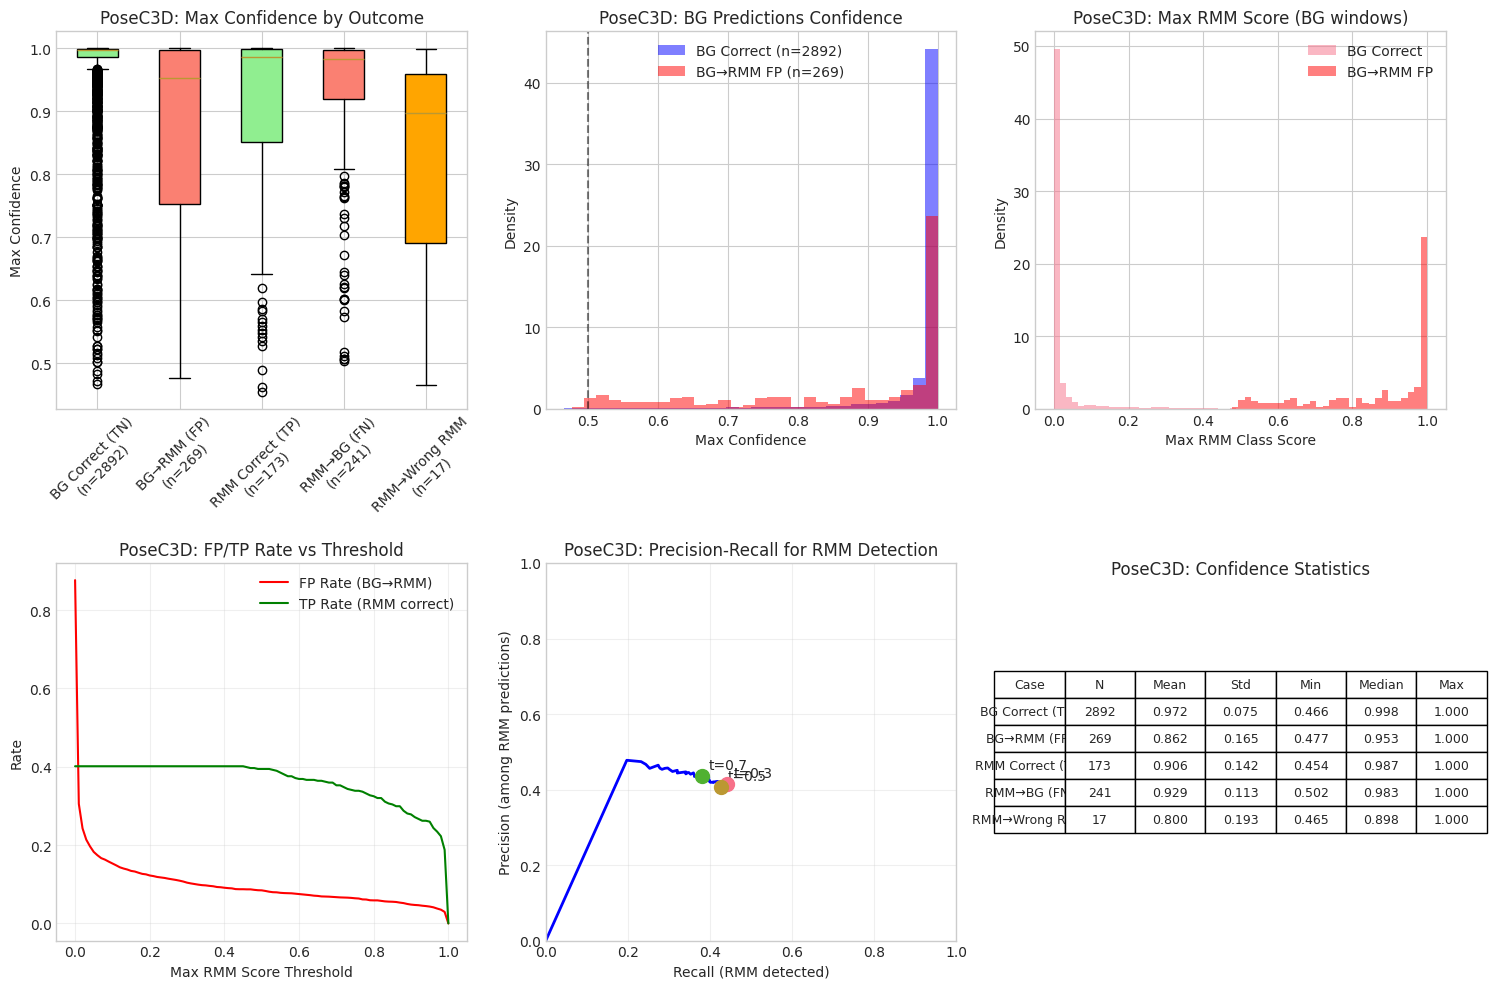

PoseC3D Balanced Confidence Analysis


/tmp/ipykernel_3976470/4244641282.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)


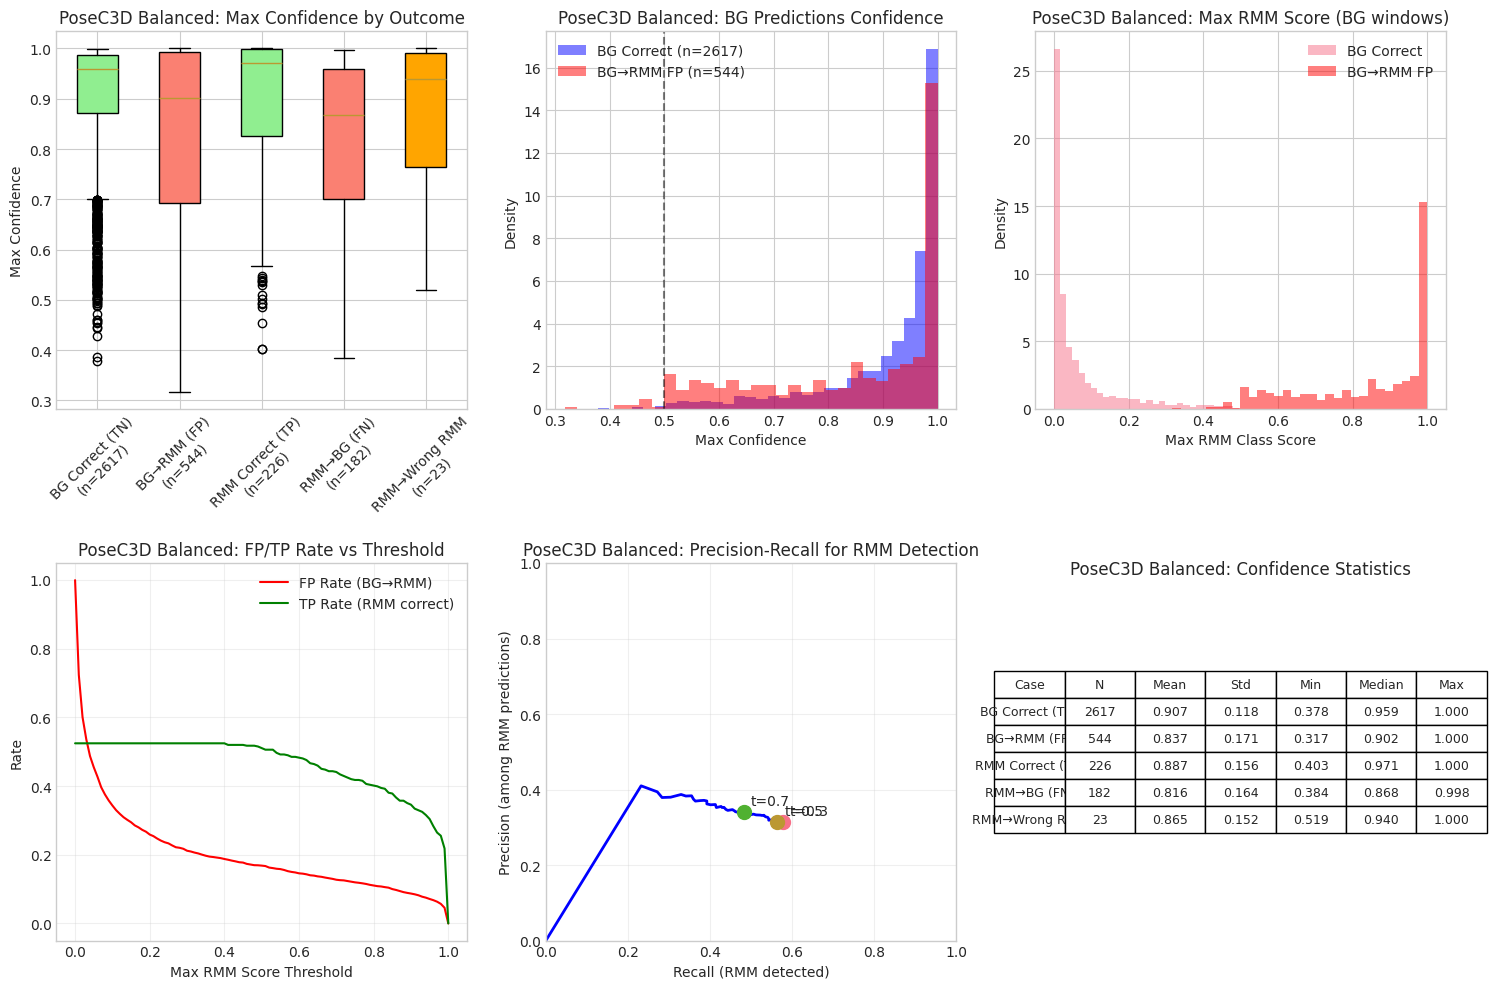

In [43]:
print("="*80)
print("PoseC3D Confidence Analysis")
print("="*80)
posec3d_cases, posec3d_conf, posec3d_rmm, posec3d_bg_scores = analyze_confidence_by_error_type(posec3d_f0, 'PoseC3D')

print("="*80)
print("PoseC3D Balanced Confidence Analysis")
print("="*80)
posec3d_bal_cases, posec3d_bal_conf, posec3d_bal_rmm, posec3d_bal_bg = analyze_confidence_by_error_type(posec3d_balanced_f0, 'PoseC3D Balanced')


### 2.7 Threshold Optimization: Finding Optimal Operating Points

Let's find thresholds that maximize different objectives:
1. **Max F1 for RMM detection**
2. **Target FP rate** (e.g., reduce BG→RMM to <5%)
3. **TAL-optimized** (maximize RMM recall while limiting FP)



V-JEPA Confidence Stats:
  Mean max confidence: 0.975
  Mean BG score: 0.839
  Mean max RMM score: 0.156
  % windows where BG > max RMM: 84.0%

PoseC3D Confidence Stats:
  Mean max confidence: 0.957
  Mean BG score: 0.859
  Mean max RMM score: 0.136
  % windows where BG > max RMM: 87.2%

PoseC3D Bal Confidence Stats:
  Mean max confidence: 0.891
  Mean BG score: 0.731
  Mean max RMM score: 0.243
  % windows where BG > max RMM: 77.9%


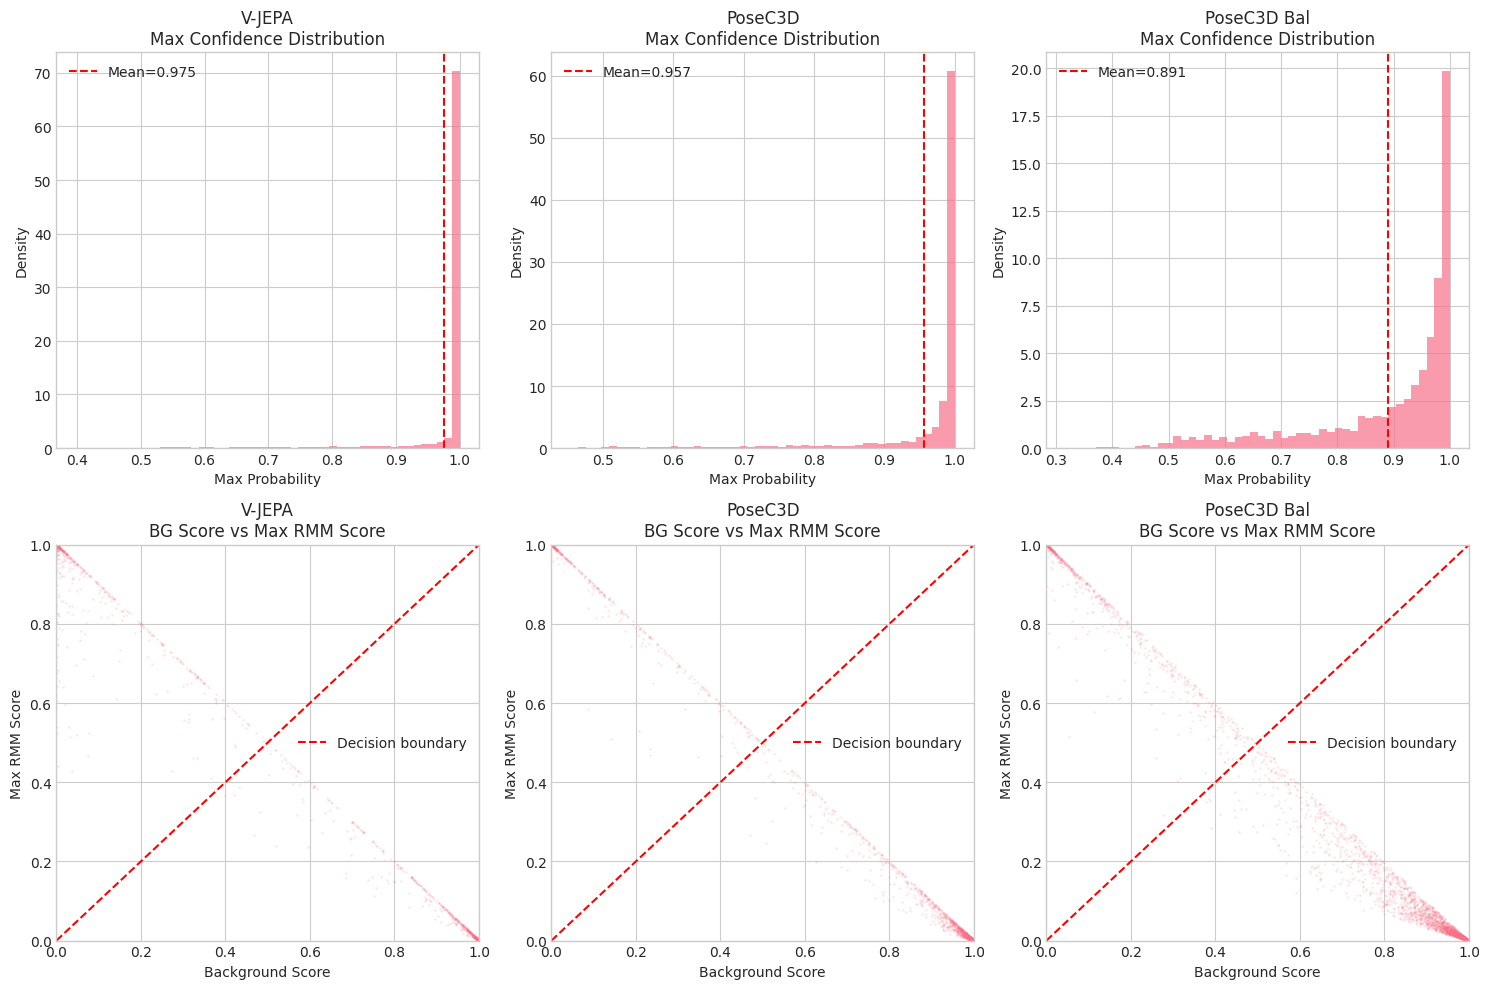


Fusion Confidence Stats:
  Mean max confidence: 0.579
  Mean BG score: 0.365
  Mean max RMM score: 0.464
  % windows where BG > max RMM: 42.5%


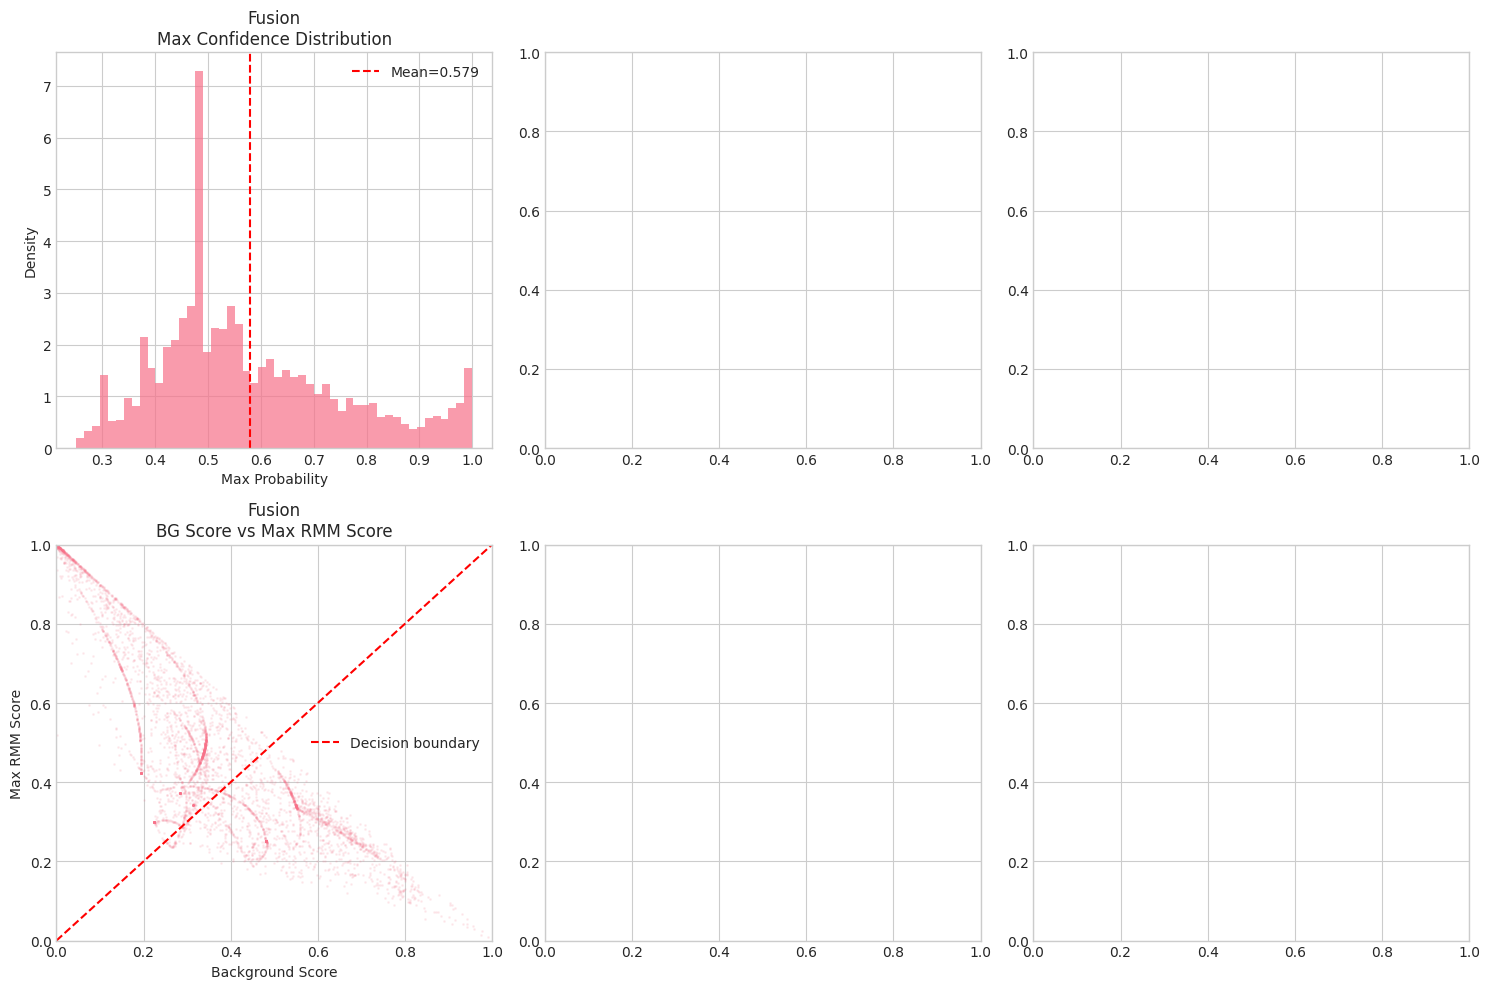

In [33]:
def plot_confidence_distributions(datasets: dict):
    """Analyze confidence score distributions."""
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for col, (model_name, df) in enumerate(datasets.items()):
        scores = get_scores_array(df)
        true_labels = df['true_label'].values.astype(int)
        
        # Max confidence (top-1 probability)
        max_conf = scores.max(axis=1)
        
        # Background vs RMM score
        bg_score = scores[:, 4]
        rmm_score = scores[:, :4].max(axis=1)  # max RMM class score
        
        # Plot max confidence distribution
        axes[0, col].hist(max_conf, bins=50, alpha=0.7, density=True)
        axes[0, col].set_title(f'{model_name}\nMax Confidence Distribution')
        axes[0, col].set_xlabel('Max Probability')
        axes[0, col].set_ylabel('Density')
        axes[0, col].axvline(max_conf.mean(), color='red', linestyle='--', 
                              label=f'Mean={max_conf.mean():.3f}')
        axes[0, col].legend()
        
        # Plot BG score vs max RMM score
        axes[1, col].scatter(bg_score, rmm_score, alpha=0.1, s=1)
        axes[1, col].plot([0, 1], [0, 1], 'r--', label='Decision boundary')
        axes[1, col].set_title(f'{model_name}\nBG Score vs Max RMM Score')
        axes[1, col].set_xlabel('Background Score')
        axes[1, col].set_ylabel('Max RMM Score')
        axes[1, col].set_xlim(0, 1)
        axes[1, col].set_ylim(0, 1)
        axes[1, col].legend()
        
        # Print stats
        print(f"\n{model_name} Confidence Stats:")
        print(f"  Mean max confidence: {max_conf.mean():.3f}")
        print(f"  Mean BG score: {bg_score.mean():.3f}")
        print(f"  Mean max RMM score: {rmm_score.mean():.3f}")
        print(f"  % windows where BG > max RMM: {(bg_score > rmm_score).mean()*100:.1f}%")
    
    plt.tight_layout()
    plt.show()


plot_confidence_distributions({
    'V-JEPA': vjepa_f0,
    'PoseC3D': posec3d_f0,
    'Fusion': fusion_f0
})


---
## Section 3: Summary and Key Findings


In [35]:
def create_summary_table(datasets: dict):
    """Create comprehensive summary table."""
    
    summary = []
    
    for model_name, df in datasets.items():
        scores = get_scores_array(df)
        true_labels = df['true_label'].values.astype(int)
        pred_labels = df['pred_label'].values.astype(int)
        
        # Accuracy
        top1_acc = (pred_labels == true_labels).mean()
        top2_acc = compute_topk_accuracy(true_labels, scores, 2)
        
        # Error analysis
        BG = 4
        bg_to_rmm = ((true_labels == BG) & (pred_labels != BG)).mean()
        rmm_to_bg = ((true_labels != BG) & (pred_labels == BG)).mean()
        
        # Prediction bias
        pred_bg_rate = (pred_labels == BG).mean()
        true_bg_rate = (true_labels == BG).mean()
        
        # RMM recall
        rmm_mask = true_labels != BG
        rmm_recall_top1 = (pred_labels[rmm_mask] == true_labels[rmm_mask]).mean()
        rmm_in_top2 = np.any(np.argsort(scores[rmm_mask], axis=1)[:, -2:] == 
                            true_labels[rmm_mask].reshape(-1, 1), axis=1).mean()
        
        summary.append({
            'Model': model_name,
            'Top-1 Acc': f'{top1_acc*100:.1f}%',
            'Top-2 Acc': f'{top2_acc*100:.1f}%',
            'BG->RMM Rate': f'{bg_to_rmm*100:.1f}%',
            'RMM->BG Rate': f'{rmm_to_bg*100:.1f}%',
            'Pred BG Rate': f'{pred_bg_rate*100:.1f}%',
            'True BG Rate': f'{true_bg_rate*100:.1f}%',
            'RMM Recall@1': f'{rmm_recall_top1*100:.1f}%',
            'RMM Recall@2': f'{rmm_in_top2*100:.1f}%'
        })
    
    return pd.DataFrame(summary)


summary_df = create_summary_table({
    'V-JEPA': vjepa_f0,
    'PoseC3D': posec3d_f0,
    'PoseC3D Bal': posec3d_balanced_f0,
    'Fusion': fusion_f0
})

print("=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(summary_df.to_string(index=False))


SUMMARY TABLE
      Model Top-1 Acc Top-2 Acc BG->RMM Rate RMM->BG Rate Pred BG Rate True BG Rate RMM Recall@1 RMM Recall@2
     V-JEPA     85.0%     95.4%        10.6%         3.8%        84.0%        90.8%        52.4%        81.5%
    PoseC3D     85.3%     96.5%         7.5%         6.7%        87.2%        88.0%        40.1%        71.9%
PoseC3D Bal     79.1%     96.8%        15.1%         5.1%        77.9%        88.0%        52.4%        76.3%
     Fusion     47.0%     93.3%        49.7%         1.4%        42.5%        90.8%        64.3%        75.8%


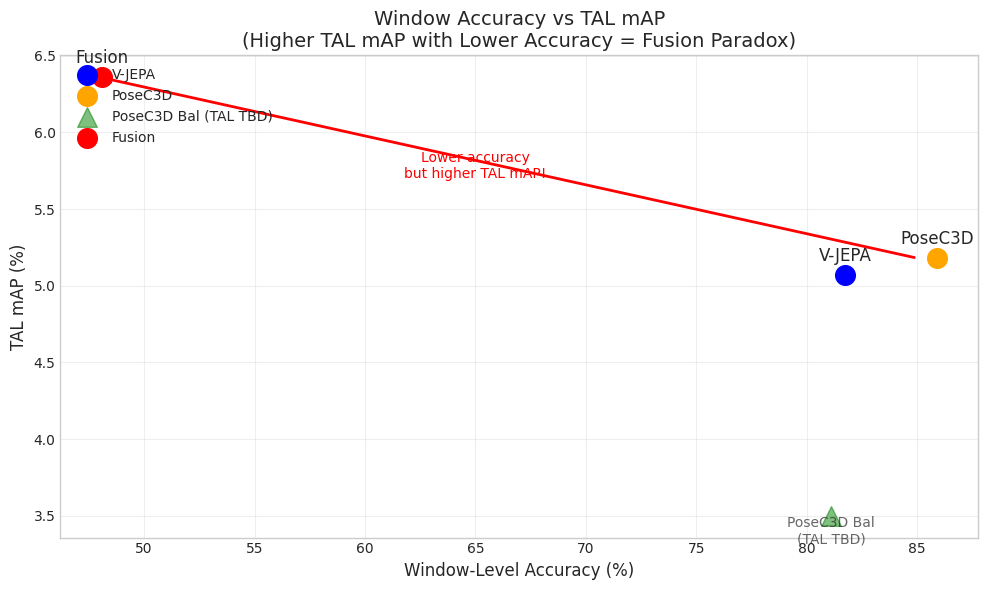


Model Comparison Summary:
Model             Window Acc    TAL mAP
----------------------------------------
V-JEPA                81.75%      5.07%
PoseC3D               85.89%      5.18%
PoseC3D Bal           81.11%        TBD
Fusion                48.10%      6.36%


In [36]:
# Final visualization: Window Accuracy vs TAL mAP
# (Manually add TAL mAP values from previous evaluation)

tal_results = {
    'V-JEPA': {'window_acc': 81.75, 'tal_map': 5.07},
    'PoseC3D': {'window_acc': 85.89, 'tal_map': 5.18},
    'PoseC3D Bal': {'window_acc': 81.11, 'tal_map': None},  # TAL mAP not yet evaluated
    'Fusion': {'window_acc': 48.10, 'tal_map': 6.36}
}

fig, ax = plt.subplots(figsize=(10, 6))

colors = {'V-JEPA': 'blue', 'PoseC3D': 'orange', 'PoseC3D Bal': 'green', 'Fusion': 'red'}
for model_name, metrics in tal_results.items():
    if metrics['tal_map'] is not None:
        ax.scatter(metrics['window_acc'], metrics['tal_map'], s=200, label=model_name, 
                   color=colors.get(model_name, 'gray'))
        ax.annotate(model_name, (metrics['window_acc'], metrics['tal_map']), 
                    textcoords="offset points", xytext=(0, 10), ha='center', fontsize=12)
    else:
        # Plot at bottom with question mark for models without TAL mAP
        ax.scatter(metrics['window_acc'], 3.5, s=200, label=f"{model_name} (TAL TBD)", 
                   color=colors.get(model_name, 'gray'), marker='^', alpha=0.5)
        ax.annotate(f"{model_name}\n(TAL TBD)", (metrics['window_acc'], 3.5), 
                    textcoords="offset points", xytext=(0, -20), ha='center', fontsize=10, alpha=0.7)

ax.set_xlabel('Window-Level Accuracy (%)', fontsize=12)
ax.set_ylabel('TAL mAP (%)', fontsize=12)
ax.set_title('Window Accuracy vs TAL mAP\n(Higher TAL mAP with Lower Accuracy = Fusion Paradox)', fontsize=14)
ax.grid(True, alpha=0.3)

# Add trend line or annotation
ax.annotate('', xy=(48, 6.36), xytext=(85, 5.18),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(65, 5.7, 'Lower accuracy\nbut higher TAL mAP!', fontsize=10, color='red', ha='center')

ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Print comparison table
print("\nModel Comparison Summary:")
print(f"{'Model':<15} {'Window Acc':>12} {'TAL mAP':>10}")
print("-" * 40)
for model_name, metrics in tal_results.items():
    tal_str = f"{metrics['tal_map']:.2f}%" if metrics['tal_map'] else "TBD"
    print(f"{model_name:<15} {metrics['window_acc']:>11.2f}% {tal_str:>10}")


---
## Key Findings

### Question 1: What does the Top-2 accuracy gap reveal?

1. **Background FP Recovery**: When background is misclassified as RMM, background is often the 2nd choice (high recovery rate)
2. **RMM Recall Improvement**: Rare classes (rocking, spinning) show larger recall improvements from top-1 to top-2
3. **Model uncertainty**: The ~10% gap suggests models are uncertain near the RMM/background decision boundary

### Question 2: Why does Fusion have lower accuracy but higher TAL mAP?

1. **Prediction Distribution Shift**: Fusion predicts background less often than single models
2. **Error Type Trade-off**: Fusion has more BG->RMM errors (hurts window accuracy) but fewer RMM->BG errors (helps TAL recall)
3. **TAL Metric Asymmetry**: TAL mAP only evaluates RMM classes, so background classification errors don't directly hurt the score
4. **Confidence Calibration**: Fusion has more spread confidence, pushing uncertain background windows toward RMM predictions

### PoseC3D Balanced Sampling Findings

The balanced sampling strategy (class_prob=[1.0, 1.0, 1.93, 9.12, 0.1]) shows:
1. **Lower overall accuracy** (81.1% vs 85.9%) due to background undersampling
2. **Slightly improved RMM recall** for some classes
3. **Rocking remains extremely difficult** - near-zero recall even with heavy oversampling
4. **High fold variance** for rare classes like spinning (0-52% F1 across folds)
5. **Trade-off**: Balanced sampling may help TAL mAP by reducing RMM->BG errors, but at cost of more BG->RMM false positives
